<a href="https://colab.research.google.com/github/diahayuuu/skripsiii/blob/main/lewatmana%3F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install osmnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 6.4 MB/s eta 0:00:00


In [2]:
# ===================================
# 1. Import & Polygon Kota Yogyakarta
# ===================================
import osmnx as ox
import pandas as pd
import numpy as np
import networkx as nx
import json
from shapely.geometry import Polygon

def get_yogyakarta_polygon():
    try:
        gdf = ox.geocode_to_gdf(
            "Kota Yogyakarta, Daerah Istimewa Yogyakarta, Indonesia"
        )
        print("Polygon berhasil diambil dari OSM")
        return gdf.geometry.values[0]
    except Exception:
        coords = [
            (110.3400,-7.7550),(110.3520,-7.7520),(110.3650,-7.7500),
            (110.3780,-7.7510),(110.3900,-7.7550),(110.4000,-7.7620),
            (110.4050,-7.7750),(110.4000,-7.7900),(110.3870,-7.8100),
            (110.3700,-7.8200),(110.3500,-7.8180),(110.3380,-7.8050),
            (110.3320,-7.7900),(110.3340,-7.7750),(110.3380,-7.7620),
            (110.3400,-7.7550),
        ]
        print("Fallback ke polygon hardcoded")
        return Polygon(coords)

YOGYA_POLYGON = get_yogyakarta_polygon()

Polygon berhasil diambil dari OSM


In [3]:
# ===============================
# 2. Download graf jaringan jalan
# ===============================
print("Mengunduh jaringan jalan Kota Yogyakarta...")

G = ox.graph_from_polygon(YOGYA_POLYGON, network_type='drive')

edges = ox.graph_to_gdfs(G, nodes=False).reset_index()
edges['osmid']   = edges['osmid'].apply(lambda x: x[0] if isinstance(x, list) else x)
edges['highway'] = edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)
edges['name']    = edges['name'].apply(lambda x: x[0] if isinstance(x, list) else x)

print(f"Total edge setelah download: {len(edges):,}")

Mengunduh jaringan jalan Kota Yogyakarta...
Total edge setelah download: 16,208


In [4]:
# =====================================================
# 3. Filter tipe jalan valid + PERBAIKAN KONEKTIVITAS
# =====================================================

TIPE_ROUTING = {
    'primary', 'secondary', 'tertiary', 'trunk',
    'primary_link', 'secondary_link', 'tertiary_link',

    # tambahan (supaya graph tersambung)
    'residential',
    'unclassified',
    'living_street'
}

KECEPATAN = {
    'primary': 40, 'secondary': 30, 'tertiary': 25,
    'trunk': 50, 'primary_link': 35,
    'secondary_link': 25, 'tertiary_link': 20,

    # tambahin juga
    'residential': 20,
    'unclassified': 20,
    'living_street': 15,
}

# ======================
# FILTER DATAFRAME (ANALISIS)
# ======================
edges_filtered = edges[edges['highway'].isin(TIPE_ROUTING)].copy()
valid_osm_ids  = set(edges_filtered['osmid'].dropna().astype('int64').unique())

print(f"Edge valid untuk analisis: {len(edges_filtered):,}")
print(f"OSM ID valid             : {len(valid_osm_ids):,}")

# ======================
# FILTER GRAPH (LEBIH AMAN)
# ======================
edges_hapus = []

for u, v, key, data in G.edges(keys=True, data=True):
    hw = data.get('highway', '')
    if isinstance(hw, list):
        hw = hw[0]

    # hanya hapus yang benar-benar tidak relevan
    if hw not in TIPE_ROUTING:
        edges_hapus.append((u, v, key))

G_filtered = G.copy()

for u, v, key in edges_hapus:
    if G_filtered.has_edge(u, v, key):
        G_filtered.remove_edge(u, v, key)

# ======================
# AMBIL KOMPONEN TERBESAR (PENTING!)
# ======================
largest_cc = max(nx.weakly_connected_components(G_filtered), key=len)
G_filtered = G_filtered.subgraph(largest_cc).copy()

print(f"Graf setelah konektivitas fix: {G_filtered.number_of_edges():,} edge")

Edge valid untuk analisis: 16,197
OSM ID valid             : 4,821
Graf setelah konektivitas fix: 16,197 edge


In [5]:
# ======================
# 4. Load dataset mobilitas
# ======================
df = pd.read_csv("/content/07.2022_4Bulan_time_of_day.csv")
df = df.rename(columns={'osm_id': 'osmid'})
df['osmid'] = pd.to_numeric(df['osmid'], errors='coerce').astype('Int64')

KOLOM_MOBILITAS = 'number_of_maid'
KOLOM_WAKTU     = 'time_of_day'
KOLOM_HARI      = 'day'
KOLOM_TIPEHARI  = 'day_type'

for kol in [KOLOM_MOBILITAS, KOLOM_WAKTU, KOLOM_HARI, KOLOM_TIPEHARI]:
    if kol not in df.columns:
        raise ValueError(f"Kolom '{kol}' tidak ditemukan. Kolom: {df.columns.tolist()}")

# Kolom tanggal — bisa 'date' atau 'date_only'
if 'date_only' not in df.columns and 'date' in df.columns:
    df['date_only'] = pd.to_datetime(df['date']).dt.date
elif 'date_only' not in df.columns:
    df['date_only'] = 'unknown'

print(f"OSM ID unik di dataset : {df['osmid'].nunique():,}")
print(f"Total baris dataset    : {len(df):,}")

OSM ID unik di dataset : 7,857
Total baris dataset    : 279,769


In [6]:
# ======================
# 5. Filter dataset ke wilayah Kota Yogyakarta
# ======================
df_kota = df[df['osmid'].isin(valid_osm_ids)].copy()
print(f"Baris setelah filter kota: {len(df_kota):,}")

Baris setelah filter kota: 77,158


In [7]:
# ====================================
# 6. Siapkan tabel info jalan dari OSM
# ====================================
def mode_first(s):
    mode = s.mode()
    return mode.iloc[0] if not mode.empty else s.iloc[0]

jalan_osm = edges_filtered[['osmid','name','highway','length','oneway']].copy()
jalan_osm = jalan_osm.dropna(subset=['name'])
jalan_osm = jalan_osm.rename(columns={'name':'name_osm'})
jalan_osm['name_osm'] = jalan_osm['name_osm'].str.lower().str.strip()
jalan_osm['osmid']    = jalan_osm['osmid'].astype('int64')

jalan_osm = (
    jalan_osm.groupby('osmid')
    .agg(
        name_osm = ('name_osm','first'),
        highway  = ('highway','first'),
        length   = ('length','sum'),   # total panjang per osmid
        oneway   = ('oneway','first'),
    )
    .reset_index()
)

In [8]:
# ================================================
# 7. Merge dataset mobilitas dengan info jalan OSM
# ================================================
df_kota['osmid'] = df_kota['osmid'].astype('int64')
df_merge = df_kota.merge(jalan_osm, on='osmid', how='inner')
df_merge['nama_jalan'] = df_merge['name_osm'].str.lower().str.strip()

sebelum = len(df_merge)
df_merge = df_merge[~df_merge['nama_jalan'].str.contains('gang', case=False, na=False)]
df_merge = df_merge[~df_merge['nama_jalan'].str.contains(r'\*', na=False)]
df_merge = df_merge[df_merge['nama_jalan'].str.startswith('jalan')]
print(f"Baris setelah cleaning: {len(df_merge):,}  (dihapus {sebelum-len(df_merge):,})")

Baris setelah cleaning: 75,047  (dihapus 1,229)


In [9]:
# ======================
# 8. Cleaning nama jalan
# ======================
df_merge['nama_jalan'] = df_merge['nama_jalan'].str.lower().str.strip()

before = len(df_merge)
df_merge = df_merge[~df_merge['nama_jalan'].str.contains('gang', case=False, na=False)]
print(f"Hapus 'gang'           : -{before - len(df_merge)} baris, sisa {len(df_merge):,}")

before = len(df_merge)
df_merge = df_merge[~df_merge['nama_jalan'].str.contains(r'\*', na=False)]
print(f"Hapus karakter bintang : -{before - len(df_merge)} baris, sisa {len(df_merge):,}")

before = len(df_merge)
df_merge = df_merge[df_merge['nama_jalan'].str.startswith('jalan')]
print(f"Filter diawali 'jalan' : -{before - len(df_merge)} baris, sisa {len(df_merge):,}")

print(f"\nTotal baris setelah cleaning: {len(df_merge):,}")

Hapus 'gang'           : -0 baris, sisa 75,047
Hapus karakter bintang : -0 baris, sisa 75,047
Filter diawali 'jalan' : -0 baris, sisa 75,047

Total baris setelah cleaning: 75,047


In [10]:
# ======================
# 9. Agregasi per nama jalan
# ======================
def mode_first(s):
    mode = s.mode()
    return mode.iloc[0] if not mode.empty else s.iloc[0]

df_agg = (
    df_merge.groupby('nama_jalan')
    .agg(
        total_length_m  = ('length', 'sum'),
        total_mobilitas = (KOLOM_MOBILITAS, 'sum'),
        tipe_jalan      = ('highway', mode_first),
        satu_arah       = ('oneway', mode_first),
    )
    .reset_index()
)

df_agg = df_agg[df_agg['total_length_m'] > 300].copy()

In [11]:
# ======================
# 10. Hitung densitas mobilitas
#     Normalisasi total mobilitas terhadap panjang jalan agar
#     jalan pendek tapi padat (seperti Malioboro) tidak dirugikan
# ======================
df_agg['densitas_mobilitas'] = df_agg['total_mobilitas'] / df_agg['total_length_m']

df_final = df_agg.sort_values('densitas_mobilitas', ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("DAFTAR JALAN KOTA YOGYAKARTA BERDASARKAN KEPADATAN")
print("=" * 60)
print(df_final[['nama_jalan', 'total_length_m', 'total_mobilitas', 'densitas_mobilitas']].head(50).to_string())
print(f"\nTotal jalan unik: {len(df_final)}")



DAFTAR JALAN KOTA YOGYAKARTA BERDASARKAN KEPADATAN
                            nama_jalan  total_length_m  total_mobilitas  densitas_mobilitas
0                      jalan gampingan      488.840721               69            0.141150
1                jalan re. martadinata    41067.816261             2801            0.068204
2                      jalan puntodewo      571.983740               39            0.068184
3                     jalan pangurakan    55804.789635             2826            0.050641
4                      jalan ganesha i      382.947949               11            0.028725
5                     jalan am sangaji    20271.585855              568            0.028020
6                   jalan cokrodipuran    22986.069159              616            0.026799
7   jalan dokter wahidin sudiro husodo   103927.239195             2743            0.026393
8                       jalan patimura      825.305928               21            0.025445
9         jalan letnan kolon

In [12]:
# ======================
# 11 — Normalisasi & Skor Kerentanan
# ======================

df_rentan = df_final.copy()

# Normalisasi densitas mobilitas ke [0, 1]
df_rentan['densitas_norm'] = (
    df_rentan['densitas_mobilitas'] - df_rentan['densitas_mobilitas'].min()
) / (df_rentan['densitas_mobilitas'].max() - df_rentan['densitas_mobilitas'].min())

# Normalisasi total mobilitas ke [0, 1]
df_rentan['mobilitas_norm'] = (
    df_rentan['total_mobilitas'] - df_rentan['total_mobilitas'].min()
) / (df_rentan['total_mobilitas'].max() - df_rentan['total_mobilitas'].min())

# Bobot penalti jalan satu arah
df_rentan['bobot_oneway'] = df_rentan['satu_arah'].apply(lambda x: 1.2 if x else 1.0)

# Skor Kerentanan
df_rentan['skor_kerentanan'] = (
    0.70 * df_rentan['densitas_norm'] +
    0.30 * df_rentan['mobilitas_norm']
) * df_rentan['bobot_oneway']

df_rentan['skor_kerentanan'] = (
    df_rentan['skor_kerentanan'] / df_rentan['skor_kerentanan'].max() * 100
).round(2)

df_rentan = df_rentan.sort_values('skor_kerentanan', ascending=False).reset_index(drop=True)

# Klasifikasi berbasis quantile
q75 = df_rentan['skor_kerentanan'].quantile(0.75)
q50 = df_rentan['skor_kerentanan'].quantile(0.50)
q25 = df_rentan['skor_kerentanan'].quantile(0.25)

def klasifikasi(s):
    if s >= q75:   return 'Sangat Tinggi'
    elif s >= q50: return 'Tinggi'
    elif s >= q25: return 'Sedang'
    else:          return 'Rendah'

df_rentan['tingkat_kerentanan'] = df_rentan['skor_kerentanan'].apply(klasifikasi)

# Lookup osmid → skor
osmid_to_skor    = {}
osmid_to_tingkat = {}
for _, row in df_merge.iterrows():
    osmid = row['osmid']
    nama  = row['nama_jalan']
    match = df_rentan[df_rentan['nama_jalan'] == nama]
    if not match.empty:
        osmid_to_skor[osmid]    = float(match.iloc[0]['skor_kerentanan'])
        osmid_to_tingkat[osmid] = match.iloc[0]['tingkat_kerentanan']

print(f"OSMID dengan skor kerentanan: {len(osmid_to_skor):,}")

distribusi = df_rentan['tingkat_kerentanan'].value_counts()
print("\nDistribusi kerentanan:")
for tingkat, jumlah in distribusi.items():
    print(f"  {tingkat:<20}: {jumlah:>3} ruas jalan")

OSMID dengan skor kerentanan: 1,114

Distribusi kerentanan:
  Sangat Tinggi       : 133 ruas jalan
  Tinggi              : 133 ruas jalan
  Sedang              : 133 ruas jalan
  Rendah              : 131 ruas jalan


In [13]:
# ===========================
# 12. Hasil akhir & ringkasan
# ===========================
print("\n" + "=" * 60)
print("ANALISIS KERENTANAN JALAN KOTA YOGYAKARTA")
print("=" * 60)

distribusi = df_rentan['tingkat_kerentanan'].value_counts()
for tingkat, jumlah in distribusi.items():
    print(f"   {tingkat:<20} : {jumlah:>3} ruas jalan")

print(f"\n   Total ruas dianalisis : {len(df_rentan)}")

print("\n" + "=" * 60)
print("TOP 20 JALAN PALING RENTAN KEMACETAN")
print("=" * 60)
print(df_rentan[['nama_jalan', 'total_length_m', 'densitas_mobilitas',
                 'skor_kerentanan', 'tingkat_kerentanan']].head(20).to_string())

# Cek posisi Malioboro secara khusus
print("\n" + "=" * 60)
print("CEK POSISI MALIOBORO")
print("=" * 60)
malioboro = df_rentan[df_rentan['nama_jalan'].str.contains('malioboro', case=False)]
if not malioboro.empty:
    print(malioboro[['nama_jalan', 'densitas_mobilitas',
                     'skor_kerentanan', 'tingkat_kerentanan']].to_string())
else:
    print("Malioboro tidak ditemukan. Kemungkinan nama di OSM berbeda.")
    print("Cek nama yang mirip:")
    print(df_rentan[df_rentan['nama_jalan'].str.contains('mali', case=False)][['nama_jalan']].head())


ANALISIS KERENTANAN JALAN KOTA YOGYAKARTA
   Sangat Tinggi        : 133 ruas jalan
   Tinggi               : 133 ruas jalan
   Sedang               : 133 ruas jalan
   Rendah               : 131 ruas jalan

   Total ruas dianalisis : 530

TOP 20 JALAN PALING RENTAN KEMACETAN
                            nama_jalan  total_length_m  densitas_mobilitas  skor_kerentanan tingkat_kerentanan
0                      jalan gampingan      488.840721            0.141150           100.00      Sangat Tinggi
1                jalan re. martadinata    41067.816261            0.068204            66.18      Sangat Tinggi
2                       jalan magelang   503141.218735            0.012961            61.65      Sangat Tinggi
3                     jalan pangurakan    55804.789635            0.050641            53.90      Sangat Tinggi
4                      jalan puntodewo      571.983740            0.068184            48.09      Sangat Tinggi
5                      jalan kyai mojo   371445.389043   

In [14]:
# ======================
# 13.Analisis Temporal
# ======================

jalan_rentan = df_rentan[
    df_rentan['tingkat_kerentanan'].isin(['Sangat Tinggi','Tinggi'])
]['nama_jalan'].tolist()

df_temporal = df_merge[df_merge['nama_jalan'].isin(jalan_rentan)].copy()

pivot_waktu = (
    df_temporal.groupby(['nama_jalan', KOLOM_TIPEHARI, KOLOM_WAKTU])[KOLOM_MOBILITAS]
    .mean().reset_index()
    .rename(columns={KOLOM_MOBILITAS: 'rata_mobilitas'})
)
waktu_puncak = (
    pivot_waktu.sort_values('rata_mobilitas', ascending=False)
    .groupby('nama_jalan').first().reset_index()
    .rename(columns={KOLOM_WAKTU:'waktu_puncak', KOLOM_TIPEHARI:'tipe_hari_puncak',
                     'rata_mobilitas':'mobilitas_puncak'})
)
df_rentan2 = df_rentan.merge(
    waktu_puncak[['nama_jalan','waktu_puncak','tipe_hari_puncak','mobilitas_puncak']],
    on='nama_jalan', how='left'
)

slot_waktu = sorted(df_merge[KOLOM_WAKTU].dropna().unique().tolist())
slot_hari  = sorted(df_merge[KOLOM_TIPEHARI].dropna().unique().tolist())
print(f"Slot waktu: {slot_waktu}")
print(f"Tipe hari : {slot_hari}")

print("\n" + "=" * 60)
print("WAKTU PUNCAK KEMACETAN PER JALAN RENTAN")
print("=" * 60)
print(df_rentan2[df_rentan2['tingkat_kerentanan'].isin(['Sangat Tinggi','Tinggi'])][
    ['nama_jalan','skor_kerentanan','tingkat_kerentanan','waktu_puncak','tipe_hari_puncak']
].head(20).to_string())

Slot waktu: ['AM Peak', 'Early Morning', 'Late Night', 'Midday', 'PM Peak']
Tipe hari : ['Weekday', 'Weekend']

WAKTU PUNCAK KEMACETAN PER JALAN RENTAN
                            nama_jalan  skor_kerentanan tingkat_kerentanan waktu_puncak tipe_hari_puncak
0                      jalan gampingan           100.00      Sangat Tinggi      PM Peak          Weekday
1                jalan re. martadinata            66.18      Sangat Tinggi   Late Night          Weekday
2                       jalan magelang            61.65      Sangat Tinggi       Midday          Weekend
3                     jalan pangurakan            53.90      Sangat Tinggi   Late Night          Weekend
4                      jalan puntodewo            48.09      Sangat Tinggi       Midday          Weekend
5                      jalan kyai mojo            46.84      Sangat Tinggi   Late Night          Weekend
6            jalan panembahan senopati            43.97      Sangat Tinggi       Midday          Weekend
7       

In [15]:
# ======================
# 14. Skor Temporal Per Slot
# ======================

KOLOM_WAKTU   = 'time_of_day'
KOLOM_TIPEHARI= 'day_type'

slot_waktu = sorted(df_merge[KOLOM_WAKTU].dropna().unique().tolist())
slot_hari  = sorted(df_merge[KOLOM_TIPEHARI].dropna().unique().tolist())

print(f"Slot waktu tersedia : {slot_waktu}")
print(f"Tipe hari tersedia  : {slot_hari}")

# Hitung skor per (day_type × time_of_day × osmid)
skor_temporal = {}
for day_type in slot_hari:
    for time_of_day in slot_waktu:
        subset = df_merge[
            (df_merge[KOLOM_TIPEHARI] == day_type) &
            (df_merge[KOLOM_WAKTU]    == time_of_day)
        ]
        if subset.empty:
            continue
        agg = subset.groupby('osmid')[KOLOM_MOBILITAS].sum().reset_index()
        agg.columns = ['osmid','mobilitas']
        mn, mx = agg['mobilitas'].min(), agg['mobilitas'].max()
        if mx == mn:
            continue
        agg['skor'] = ((agg['mobilitas'] - mn) / (mx - mn) * 100).round(2)
        key = f"{day_type}|{time_of_day}"
        skor_temporal[key] = dict(zip(agg['osmid'].astype(int), agg['skor']))

print(f"Slot temporal dihitung: {len(skor_temporal)}")

Slot waktu tersedia : ['AM Peak', 'Early Morning', 'Late Night', 'Midday', 'PM Peak']
Tipe hari tersedia  : ['Weekday', 'Weekend']
Slot temporal dihitung: 10


In [16]:
# ======================
# 15. HEATMAP: Distribusi mobilitas per waktu × tipe hari
#     untuk semua jalan rentan secara agregat
# ======================
heatmap_data = (
    df_temporal
    .groupby([KOLOM_TIPEHARI, KOLOM_WAKTU])[KOLOM_MOBILITAS]
    .sum()
    .reset_index()
    .pivot(index=KOLOM_TIPEHARI, columns=KOLOM_WAKTU, values=KOLOM_MOBILITAS)
    .fillna(0)
)

print("\n" + "=" * 60)
print("HEATMAP TOTAL MOBILITAS (JALAN RENTAN) — Weekday vs Weekend")
print("=" * 60)
print(heatmap_data.to_string())


HEATMAP TOTAL MOBILITAS (JALAN RENTAN) — Weekday vs Weekend
time_of_day  AM Peak  Early Morning  Late Night  Midday  PM Peak
day_type                                                        
Weekday        17603           6913       21801   28557    15992
Weekend         7094           2605        9113   12147     6462


In [17]:
# ======================
# 16. Ringkasan per time_of_day untuk top 10 jalan rentan
# ======================
top10 = df_rentan2[
    df_rentan['tingkat_kerentanan'].isin(['Sangat Tinggi', 'Tinggi'])
]['nama_jalan'].head(10).tolist()

df_top10_temporal = (
    df_temporal[df_temporal['nama_jalan'].isin(top10)]
    .groupby(['nama_jalan', KOLOM_WAKTU])[KOLOM_MOBILITAS]
    .sum()
    .reset_index()
    .pivot(index='nama_jalan', columns=KOLOM_WAKTU, values=KOLOM_MOBILITAS)
    .fillna(0)
    .astype(int)
)

print("\n" + "=" * 60)
print("DISTRIBUSI MOBILITAS PER WAKTU — TOP 10 JALAN PALING RENTAN")
print("=" * 60)
print(df_top10_temporal.to_string())



DISTRIBUSI MOBILITAS PER WAKTU — TOP 10 JALAN PALING RENTAN
time_of_day                AM Peak  Early Morning  Late Night  Midday  PM Peak
nama_jalan                                                                    
jalan gampingan                 11              2          10      32       14
jalan jenderal sudirman        746            334        1049    1511      649
jalan kyai mojo                762            596        1390    1235      693
jalan magelang                1358            504        1221    2252     1186
jalan panembahan senopati      802            251         806    1607      868
jalan pangurakan               418            221         789     813      585
jalan puntodewo                  4              5           7      21        2
jalan r.e. martadinata         769            508        1608    1361     1077
jalan re. martadinata          386            273         867     719      556
jalan yos sudarso              465            135         761     829 

In [ ]:
# ======================
# Export hasil lengkap
# ======================
df_rentan2.to_csv('kerentanan_dengan_waktu_puncak.csv',
                  index=False, encoding='utf-8-sig')
df_koridor.to_csv('koridor_rute_dominan.csv',
                  index=False, encoding='utf-8-sig')
df_top10_temporal.to_csv('heatmap_top10_jalan.csv', encoding='utf-8-sig')

from google.colab.files import download
download('kerentanan_dengan_waktu_puncak.csv')
download('koridor_rute_dominan.csv')
download('heatmap_top10_jalan.csv')

print("\n✓ Semua file berhasil didownload")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Semua file berhasil didownload


In [18]:
# ======================
# 17. — Peta Kerentanan
# ======================

!pip install folium -q

import plotly.graph_objects as go
import pandas as pd
from shapely.geometry import LineString, MultiLineString

# ======================
# FUNGSI AMBIL COORDS (AMAN)
# ======================
def ambil_coords(geom):
    coords = []
    if isinstance(geom, LineString):
        coords.extend(list(geom.coords))
    elif isinstance(geom, MultiLineString):
        for g in geom.geoms:
            coords.extend(list(g.coords))
    return coords


# ======================
# 1. AMBIL EDGE OSM
# ======================
edges_geo = ox.graph_to_gdfs(G, nodes=False).reset_index()

edges_geo['osmid'] = edges_geo['osmid'].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

edges_geo['name'] = edges_geo['name'].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

edges_geo['osmid'] = pd.to_numeric(edges_geo['osmid'], errors='coerce')
edges_geo['name']  = edges_geo['name'].astype(str).str.lower().str.strip()

# ======================
# 2. PREPARE KEY
# ======================
df_rentan2['nama_jalan_key'] = df_rentan2['nama_jalan'].astype(str).str.lower().str.strip()
edges_geo['nama_jalan_key']  = edges_geo['name']

# ======================
# 3. MERGE
# ======================
edges_scored = edges_geo.merge(
    df_rentan2[[
        'nama_jalan_key',
        'skor_kerentanan',
        'tingkat_kerentanan',
        'waktu_puncak',
        'tipe_hari_puncak'
    ]],
    on='nama_jalan_key',
    how='left'
)

# ======================
# 4. CLEAN DATA
# ======================
edges_scored = edges_scored.fillna({
    'skor_kerentanan': 0,
    'tingkat_kerentanan': 'Rendah',
    'waktu_puncak': '-',
    'tipe_hari_puncak': '-'
})

edges_scored['nama_jalan_key'] = edges_scored['nama_jalan_key'].fillna('tanpa nama')

# 🔥 FILTER JALAN PENDEK (biar gak noisy)
edges_scored = edges_scored[edges_scored['length'] > 30]

print(f"Edge setelah filtering: {len(edges_scored):,}")

# ======================
# 5. SET WARNA & STYLE
# ======================
warna_map = {
    'Sangat Tinggi': '#d62828',
    'Tinggi'       : '#f77f00',
}

fig = go.Figure()

# ======================
# 6. DRAW LINE (FOKUS)
# ======================
for tingkat, warna in warna_map.items():

    subset = edges_scored[edges_scored['tingkat_kerentanan'] == tingkat]
    if subset.empty:
        continue

    lats, lons = [], []

    for _, row in subset.iterrows():

        if row['geometry'] is None:
            continue

        coords = ambil_coords(row['geometry'])
        if not coords:
            continue

        for lon, lat in coords:
            lats.append(lat)
            lons.append(lon)

        lats.append(None)
        lons.append(None)

    # styling beda per level
    width = 4 if tingkat == 'Sangat Tinggi' else 2.5
    opacity = 0.9 if tingkat == 'Sangat Tinggi' else 0.7

    fig.add_trace(go.Scattermapbox(
        lat=lats,
        lon=lons,
        mode='lines',
        line=dict(width=width, color=warna),
        name=tingkat,
        hoverinfo='skip'
    ))

# ======================
# 7. HOVER INFO (TITIK)
# ======================
for tingkat, warna in warna_map.items():

    subset = edges_scored[edges_scored['tingkat_kerentanan'] == tingkat]
    if subset.empty:
        continue

    hover_lat, hover_lon, hover_text = [], [], []

    for _, row in subset.iterrows():

        if row['geometry'] is None:
            continue

        point = row['geometry'].representative_point()

        hover_lat.append(point.y)
        hover_lon.append(point.x)

        nama = str(row['nama_jalan_key'])

        hover_text.append(
            f"<b>{nama.title()}</b><br>"
            f"Skor: {row['skor_kerentanan']}<br>"
            f"Tingkat: {tingkat}<br>"
            f"Waktu Puncak: {row['waktu_puncak']}<br>"
            f"Tipe Hari: {row['tipe_hari_puncak']}"
        )

    fig.add_trace(go.Scattermapbox(
        lat=hover_lat,
        lon=hover_lon,
        mode='markers',
        marker=dict(size=6, color=warna, opacity=0),
        hovertext=hover_text,
        hoverinfo='text',
        showlegend=False
    ))

# ======================
# 8. AUTO CENTER
# ======================
centroids = edges_scored.geometry.dropna().apply(lambda g: g.representative_point())

min_lat = centroids.y.min()
max_lat = centroids.y.max()
min_lon = centroids.x.min()
max_lon = centroids.x.max()

# ======================
# 9. LAYOUT (BERSIH)
# ======================
fig.update_layout(
    mapbox=dict(
        style='carto-positron',  # clean light
        center=dict(
            lat=(min_lat + max_lat) / 2,
            lon=(min_lon + max_lon) / 2,
        ),
        zoom=13,
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=650,
    title=dict(
        text='Peta Kerentanan Kemacetan Kota Yogyakarta (Fokus Jalan Utama)',
        x=0.5
    ),
    legend=dict(
        title='Tingkat Kerentanan',
        bgcolor='white',
        bordercolor='lightgrey',
        borderwidth=1,
    )
)

fig.show()

Edge setelah filtering: 12,015


In [19]:
# ================================
# 18 — FUNGSI BANGUN GRAF BERBOBOT
# ================================
import math
import numpy as np
import networkx as nx

PENALTI_K = 2.5  # diturunkan biar tidak terlalu ekstrem

def bangun_graf_berbobot(G_orig, osmid_skor_dict, kecepatan_map):

    G_di = nx.MultiDiGraph()

    for u, v, key, data in G_orig.edges(keys=True, data=True):

        panjang = float(data.get('length', 50))

        osmid   = data.get('osmid')
        highway = data.get('highway', 'tertiary')
        nama    = data.get('name', '')
        geom    = data.get('geometry')

        # handle list dari OSM
        if isinstance(osmid, list):   osmid   = osmid[0]
        if isinstance(highway, list): highway = highway[0]
        if isinstance(nama, list):    nama    = nama[0]

        # ======================
        # KECEPATAN (SAFE)
        # ======================
        kecepatan = kecepatan_map.get(str(highway), 25)
        if kecepatan <= 0:
            kecepatan = 25

        waktu_detik = (panjang / 1000.0) / kecepatan * 3600.0

        # ======================
        # SKOR (SAFE + CLAMP)
        # ======================
        skor = osmid_skor_dict.get(osmid, 0)
        skor = max(0, min(100, float(skor)))  # hindari outlier

        # ======================
        # PENALTI (STABIL)
        # ======================
        faktor_penalti = math.exp(PENALTI_K * skor / 100.0)

        # ======================
        # COST FINAL (INI INTI)
        # ======================
        cost = waktu_detik * faktor_penalti   # ❗ TANPA round

        # klasifikasi
        tingkat = (
            'Sangat Tinggi' if skor >= 75 else
            'Tinggi'        if skor >= 50 else
            'Sedang'        if skor >= 25 else 'Rendah'
        )

        edge_attr = {
            'length'      : panjang,
            'waktu_detik' : waktu_detik,
            'skor_rentan' : skor,
            'tingkat'     : tingkat,
            'nama_jalan'  : str(nama).strip(),
            'bobot_custom': cost,
            'highway'     : str(highway),
        }

        if geom is not None:
            edge_attr['geometry'] = geom

        # ======================
        # PILIH EDGE TERBAIK (MIN COST)
        # ======================
        # if G_di.has_edge(u, v):
        #     if cost < G_di[u][v]['bobot_custom']:
        #         G_di[u][v].update(edge_attr)
        # else:
        #     G_di.add_edge(u, v, **edge_attr)

        G_di.add_edge(u, v, **edge_attr)

    # ======================
    # COPY NODE ATTR (WAJIB)
    # ======================
    for node, attr in G_orig.nodes(data=True):
        if node in G_di.nodes:
            G_di.nodes[node].update(attr)

    G_di.graph = G_orig.graph.copy()

    return G_di


# ======================
# BUILD GRAF TEMPORAL
# ======================
print("Membangun graf berbobot per slot waktu...")

GRAF_TEMPORAL = {}

for slot_key, osmid_skor in skor_temporal.items():
    GRAF_TEMPORAL[slot_key] = bangun_graf_berbobot(
        G_filtered, osmid_skor, KECEPATAN
    )
    print(f"  ✓ {slot_key}")

GRAF_TEMPORAL['Semua Hari|Semua Waktu'] = bangun_graf_berbobot(
    G_filtered, osmid_to_skor, KECEPATAN
)

print("  ✓ Semua Hari|Semua Waktu (default)")


# ======================
# THRESHOLD (AMAN)
# ======================
semua_skor = [
    d.get('skor_rentan', 0)
    for _, _, d in GRAF_TEMPORAL['Semua Hari|Semua Waktu'].edges(data=True)
    if d.get('skor_rentan', 0) > 0
]

if semua_skor:
    THRESH_RENTAN = round(np.percentile(semua_skor, 75), 1)
    THRESH_AMAN   = round(np.percentile(semua_skor, 25), 1)
else:
    THRESH_RENTAN = 50
    THRESH_AMAN   = 25

print(f"\nThreshold rentan (Q75): {THRESH_RENTAN}")
print(f"Threshold aman   (Q25): {THRESH_AMAN}")

Membangun graf berbobot per slot waktu...
  ✓ Weekday|AM Peak
  ✓ Weekday|Early Morning
  ✓ Weekday|Late Night
  ✓ Weekday|Midday
  ✓ Weekday|PM Peak
  ✓ Weekend|AM Peak
  ✓ Weekend|Early Morning
  ✓ Weekend|Late Night
  ✓ Weekend|Midday
  ✓ Weekend|PM Peak
  ✓ Semua Hari|Semua Waktu (default)

Threshold rentan (Q75): 4.9
Threshold aman   (Q25): 1.0


In [20]:
# =======================================================
# 19 — FUNGSI ROUTING (Jaccard + Yen K-Diverse + ANALISIS)
# ========================================================
def jaccard_similarity(path_a, path_b):
    ea = set(zip(path_a[:-1], path_a[1:]))
    eb = set(zip(path_b[:-1], path_b[1:]))
    if not ea or not eb:
        return 0
    return len(ea & eb) / len(ea | eb)


def yen_k_diverse(G, source, target, K=3,
                  weight='bobot_custom',
                  max_similarity=0.6,
                  max_detour=0.6,
                  max_iter=500):
    """
    K-Shortest Paths dengan filter diversitas & detour.
    Detour diukur berdasarkan JARAK (meter), bukan bobot —
    agar user tidak diberi rute yang jauh sekali.
    """
    try:
        generator = nx.shortest_simple_paths(G, source, target, weight=weight)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return []

    hasil        = []
    jarak_normal = None
    iterasi      = 0

    for path in generator:
        if len(hasil) >= K:
            break
        iterasi += 1
        if iterasi > max_iter:   # ← batas aman
            break

        jarak = sum(
            G[path[i]][path[i+1]].get('length', 0)
            for i in range(len(path)-1)
            if G.has_edge(path[i], path[i+1])
        )

        if jarak_normal is None:
            jarak_normal = jarak if jarak > 0 else 1

        if jarak > jarak_normal * (1 + max_detour):
            continue

        terlalu_mirip = any(
            jaccard_similarity(path, r) > max_similarity
            for r in hasil
        )
        if terlalu_mirip:
            continue

        hasil.append(path)

    return hasil


# def analisis_rute(G, path):
#     """Analisis satu rute: jarak, waktu asli, jalan rentan."""
#     if not path or len(path) < 2:
#         return None

#     total_jarak = 0
#     total_waktu = 0  # waktu ASLI (tanpa penalti) dalam detik
#     jalan_list  = []

#     for i in range(len(path)-1):
#         u, v = path[i], path[i+1]

#         if not G.has_edge(u, v):
#             continue

#         # edge    = G[u][v]

#         edges = G.get_edge_data(u, v)

#         if not edges:
#             continue

#         # ambil edge TERBAIK (berdasarkan cost)
#         edge = min(
#             edges.values(),
#             key=lambda x: x.get('bobot_custom', float('inf'))
#         )

#         panjang = edge.get('length', 0)
#         total_jarak += panjang

#         # Waktu ASLI tanpa penalti untuk ditampilkan ke user
#         total_waktu += edge.get('waktu_detik', 0)
#         nama    = edge.get('nama_jalan', '')

#         if isinstance(nama, list): nama = nama[0]
#         skor    = edge.get('skor_rentan', 0)
#         tingkat = edge.get('tingkat', 'Rendah')

#         if str(nama).strip():
#             jalan_list.append({
#                 'nama': str(nama).title(),
#                 'skor': float(skor),
#                 'tingkat': tingkat,
#                 'panjang': panjang,
#             })

#     menit = int(total_waktu // 60)
#     detik = int(total_waktu % 60)

#     if not jalan_list:
#         return {
#             'jarak_km': round(total_jarak/1000, 2),
#             'waktu_str': f"{menit} mnt {detik} dtk",
#             'waktu_total': total_waktu,
#             'n_rentan': 0,
#             'jalan_rentan': [], 'jalan_aman': [],
#         }

#     df_j = pd.DataFrame(jalan_list).groupby('nama').agg(
#         panjang=('panjang','sum'),
#         skor=('skor','max'),
#         tingkat=('tingkat','first')
#     ).reset_index()

#     rentan = df_j[df_j['skor'] >= THRESH_RENTAN]
#     aman   = df_j[df_j['skor'] <  THRESH_AMAN]

#     return {
#         'jarak_km'    : round(total_jarak/1000, 2),
#         'waktu_str'   : f"{menit} mnt {detik} dtk",
#         'waktu_total' : total_waktu,
#         'n_rentan'    : int(len(rentan)),
#         'jalan_rentan': rentan['nama'].tolist()[:5],
#         'jalan_aman'  : aman['nama'].tolist()[:5],
#     }


# def koordinat_path(G_multi, path):
#     """
#     Ambil koordinat rute mengikuti GEOMETRI JALAN OSM.
#     Memakai G_multi (MultiDiGraph asli) karena geometry ada di sana.
#     Hasil: list of [lat, lon] untuk Leaflet.

#     PERBAIKAN rute melayang:
#     - Setiap edge dicoba dengan geometri OSM dulu
#     - Jika tidak ada, fallback ke koordinat node (garis lurus antar simpang)
#     - Deduplikasi titik berurutan agar rute mulus
#     """
#     coords = []
#     last_coord = None

#     for i in range(len(path) - 1):
#         u, v = path[i], path[i+1]
#         seg_coords = []

#         if G_multi.has_edge(u, v):
#             # Ambil edge dengan geometri jika ada
#             best_geom = None
#             for key, data in G_multi[u][v].items():
#                 if 'geometry' in data:
#                     best_geom = data['geometry']
#                     break

#             if best_geom is not None:
#                 from shapely.geometry import LineString, MultiLineString

#                 def koordinat_path(G_multi, path):
#                     coords     = []
#                     last_coord = None

#                     for i in range(len(path) - 1):
#                         u, v = path[i], path[i+1]
#                         seg_coords = []

#                         if G_multi.has_edge(u, v):
#                             best_geom = None
#                             for key, data in G_multi[u][v].items():
#                                 if 'geometry' in data:
#                                     best_geom = data['geometry']
#                                     break

#                             if best_geom is not None:
#                                 if isinstance(best_geom, LineString):
#                                     for lon, lat in best_geom.coords:
#                                         seg_coords.append([lat, lon])
#                                 elif isinstance(best_geom, MultiLineString):
#                                     for line in best_geom.geoms:
#                                         for lon, lat in line.coords:
#                                             seg_coords.append([lat, lon])
#                             else:
#                                 if u in G_multi.nodes:
#                                     seg_coords.append([G_multi.nodes[u]['y'], G_multi.nodes[u]['x']])
#                                 if v in G_multi.nodes:
#                                     seg_coords.append([G_multi.nodes[v]['y'], G_multi.nodes[v]['x']])
#                         else:
#                             for node in (u, v):
#                                 if node in G_multi.nodes:
#                                     seg_coords.append([G_multi.nodes[node]['y'], G_multi.nodes[node]['x']])

#                         for c in seg_coords:
#                             if c != last_coord:
#                                 coords.append(c)
#                                 last_coord = c

#             return coords

def analisis_rute(G, path):

    if not path or len(path) < 2:
        return None

    total_jarak = 0
    total_waktu = 0
    jalan_list  = []

    for i in range(len(path)-1):
        u, v = path[i], path[i+1]

        edges = G.get_edge_data(u, v)

        if not edges:
            continue

        edge = min(
            edges.values(),
            key=lambda x: x.get('bobot_custom', float('inf'))
        )

        panjang = edge.get('length', 0)
        total_jarak += panjang
        total_waktu += edge.get('waktu_detik', 0)

        nama    = edge.get('nama_jalan', '')
        skor    = edge.get('skor_rentan', 0)
        tingkat = edge.get('tingkat', 'Rendah')

        if isinstance(nama, list):
            nama = nama[0]

        if str(nama).strip():
            jalan_list.append({
                'nama': str(nama).title(),
                'skor': float(skor),
                'tingkat': tingkat,
                'panjang': panjang,
            })

    menit = int(total_waktu // 60)
    detik = int(total_waktu % 60)

    # if not jalan_list:
    #     return {
    #         'jarak_km': round(total_jarak/1000, 2),
    #         'waktu_str': f"{menit} mnt {detik} dtk",
    #         'waktu_total': total_waktu,
    #         'n_rentan': 0,
    #         'jalan_rentan': [],
    #         'jalan_aman': [],
    #     }

    if total_jarak == 0 and total_waktu == 0:
      return None

    df_j = pd.DataFrame(jalan_list).groupby('nama').agg(
        panjang=('panjang','sum'),
        skor=('skor','max'),
        tingkat=('tingkat','first')
    ).reset_index()

    rentan = df_j[df_j['skor'] >= THRESH_RENTAN]
    aman   = df_j[df_j['skor'] <  THRESH_AMAN]

    return {
        'jarak_km'    : round(total_jarak/1000, 2),
        'waktu_str'   : f"{menit} mnt {detik} dtk",
        'waktu_total' : total_waktu,
        'n_rentan'    : int(len(rentan)),
        'jalan_rentan': rentan['nama'].tolist()[:5],
        'jalan_aman'  : aman['nama'].tolist()[:5],
    }


def koordinat_path(G, path):

    coords = []

    for u, v in zip(path[:-1], path[1:]):

        if not G.has_edge(u, v):
            continue

        data = G.get_edge_data(u, v)

        # handle MultiDiGraph / Graph
        if isinstance(data, dict) and 0 in data:
            data = data[0]

        geom = data.get('geometry', None)

        # ======================
        # KASUS 1: ADA GEOMETRY
        # ======================
        if geom is not None:
            try:
                if hasattr(geom, "coords"):
                    for lon, lat in geom.coords:
                        coords.append([lat, lon])
                    continue
            except:
                pass

        # ======================
        # KASUS 2: TIDAK ADA GEOMETRY → fallback ke node
        # ======================
        try:
            lat1 = G.nodes[u]['y']
            lon1 = G.nodes[u]['x']
            lat2 = G.nodes[v]['y']
            lon2 = G.nodes[v]['x']

            coords.append([lat1, lon1])
            coords.append([lat2, lon2])

        except:
            continue

    return coords

In [21]:
# ======================
# 20 — VALIDASI LANDMARK
# ======================
LOKASI_KANDIDAT = {
    'Tugu Yogyakarta'    : (-7.7829, 110.3670),
    'Malioboro'          : (-7.7930, 110.3656),
    'Stasiun Tugu'       : (-7.7892, 110.3642),
    'Keraton Yogyakarta' : (-7.8053, 110.3642),
    'Pasar Beringharjo'  : (-7.7989, 110.3641),
    'Alun-Alun Utara'    : (-7.8000, 110.3642),
    'Alun-Alun Selatan'  : (-7.8120, 110.3673),  # Jl. Brigjen Katamso
    'Benteng Vredeburg'  : (-7.7952, 110.3664),
    'Pasar Giwangan'     : (-7.8280, 110.3855),  # pasar di sebelah terminal, jalan dua arah
    'Kotagede'           : (-7.8297, 110.3972),
    'Stasiun Lempuyangan': (-7.7898, 110.3756),
    'Pasar Kranggan'     : (-7.7848, 110.3718),
    'Prawirotaman'       : (-7.8107, 110.3721),
    'RS Bethesda'        : (-7.7843, 110.3816),
    'Pasar Demangan'     : (-7.7849, 110.3779),
    'Jetis'              : (-7.7760, 110.3650),
    'Ngampilan'          : (-7.8020, 110.3601),
    'Wirobrajan'         : (-7.8012, 110.3554),
    'Gedongtengen'       : (-7.7892, 110.3608),
    'Pakualaman'         : (-7.7992, 110.3724),
}

G_default = GRAF_TEMPORAL['Semua Hari|Semua Waktu']

LOKASI_VALID = {}
node_per_lokasi = {}

print("Validasi landmark (FINAL FIX):")

for nama, (lat, lon) in LOKASI_KANDIDAT.items():
    try:
        node = ox.distance.nearest_nodes(G_filtered, lon, lat)

        # 🔥 LANGSUNG MASUKKAN (JANGAN DI-FILTER LAGI)
        LOKASI_VALID[nama] = (lat, lon)
        node_per_lokasi[nama] = node

        print(f"  ✓ {nama}")

    except Exception as e:
        print(f"  ❌ {nama} error: {e}")

print(f"\n✓ {len(LOKASI_VALID)} lokasi valid")

Validasi landmark (FINAL FIX):
  ✓ Tugu Yogyakarta
  ✓ Malioboro
  ✓ Stasiun Tugu
  ✓ Keraton Yogyakarta
  ✓ Pasar Beringharjo
  ✓ Alun-Alun Utara
  ✓ Alun-Alun Selatan
  ✓ Benteng Vredeburg
  ✓ Pasar Giwangan
  ✓ Kotagede
  ✓ Stasiun Lempuyangan
  ✓ Pasar Kranggan
  ✓ Prawirotaman
  ✓ RS Bethesda
  ✓ Pasar Demangan
  ✓ Jetis
  ✓ Ngampilan
  ✓ Wirobrajan
  ✓ Gedongtengen
  ✓ Pakualaman

✓ 20 lokasi valid


In [22]:
# ======================
# 21. Lookup node per lokasi valid
# ======================

nama_list = list(LOKASI_VALID.keys())
lats = [LOKASI_VALID[n][0] for n in nama_list]
lons = [LOKASI_VALID[n][1] for n in nama_list]

nodes = ox.distance.nearest_nodes(G_filtered, lons, lats)

node_per_lokasi = dict(zip(nama_list, nodes))

In [23]:
# ======================
# REBUILD G_default — jalankan sebelum cell 22
# G_default rusak karena edge dihapus di sesi sebelumnya
# Rebuild dari G_filtered yang masih bersih
# ======================

print("Cek G_filtered...")
print(f"  Edges : {G_filtered.number_of_edges():,}")
print(f"  Nodes : {G_filtered.number_of_nodes():,}")

# Cek apakah G_filtered masih utuh
na = ox.distance.nearest_nodes(G_filtered, 110.3656, -7.7930)  # Malioboro
nb = ox.distance.nearest_nodes(G_filtered, 110.3642, -7.8053)  # Keraton
print(f"  G_filtered Malioboro→Keraton: "
      f"{'✓ terhubung' if nx.has_path(G_filtered, na, nb) else '❌ RUSAK'}")

# Rebuild G_default dari G_filtered + osmid_to_skor
print("\nRebuilding G_default dari G_filtered...")
G_default = bangun_graf_berbobot(G_filtered, osmid_to_skor, KECEPATAN)

# Hitung threshold ulang
semua_skor_nonzero = [
    d.get('skor_rentan', 0)
    for u, v, d in G_default.edges(data=True)
    if d.get('skor_rentan', 0) > 0
]
THRESH_RENTAN = round(np.percentile(semua_skor_nonzero, 75), 1)
THRESH_AMAN   = round(np.percentile(semua_skor_nonzero, 25), 1)

# Rebuild GRAF_TEMPORAL
print("Rebuilding GRAF_TEMPORAL...")
GRAF_TEMPORAL = {}
for slot_key, osmid_skor in skor_temporal.items():
    GRAF_TEMPORAL[slot_key] = bangun_graf_berbobot(
        G_filtered, osmid_skor, KECEPATAN
    )
GRAF_TEMPORAL['Semua Hari|Semua Waktu'] = G_default
print(f"  ✓ {len(GRAF_TEMPORAL)} slot waktu")

# Rebuild node_per_lokasi dari G_filtered
print("Rebuilding node_per_lokasi...")
nama_list = list(LOKASI_VALID.keys())
lats = [LOKASI_VALID[n][0] for n in nama_list]
lons = [LOKASI_VALID[n][1] for n in nama_list]
nodes = ox.distance.nearest_nodes(G_filtered, lons, lats)
node_per_lokasi = dict(zip(nama_list, nodes))

# Verifikasi
print("\nVerifikasi setelah rebuild:")
sampel = [
    ('Malioboro',     'Keraton Yogyakarta'),
    ('Stasiun Tugu',  'Kotagede'),
    ('Pasar Kranggan','Alun-Alun Selatan'),
    ('Tugu Yogyakarta','Prawirotaman'),
    ('Benteng Vredeburg','Pasar Giwangan'),
]
semua_ok = True
for a, b in sampel:
    na = node_per_lokasi.get(a)
    nb = node_per_lokasi.get(b)
    if na and nb:
        ada = nx.has_path(G_default, na, nb)
        print(f"  {a} → {b}: "
              f"{'✓' if ada else '❌ MASIH TIDAK TERHUBUNG'}")
        if not ada:
            semua_ok = False

print()
if semua_ok:
    print("✓ G_default sehat — lanjut ke cell 22")
else:
    print("❌ G_default masih bermasalah")
    print("  Kemungkinan G_filtered juga sudah rusak.")
    print("  Perlu jalankan ulang dari cell 3 (download graf).")

Cek G_filtered...
  Edges : 16,197
  Nodes : 6,688
  G_filtered Malioboro→Keraton: ✓ terhubung

Rebuilding G_default dari G_filtered...
Rebuilding GRAF_TEMPORAL...
  ✓ 11 slot waktu
Rebuilding node_per_lokasi...

Verifikasi setelah rebuild:
  Malioboro → Keraton Yogyakarta: ✓
  Stasiun Tugu → Kotagede: ✓
  Pasar Kranggan → Alun-Alun Selatan: ✓
  Tugu Yogyakarta → Prawirotaman: ✓
  Benteng Vredeburg → Pasar Giwangan: ✓

✓ G_default sehat — lanjut ke cell 22


In [24]:
# Jalankan SEKALI setelah rebuild G_default
print("Konversi G_default → G_simple...")

G_simple = nx.DiGraph()

for u, v, data in G_default.edges(data=True):
    bobot = data.get('bobot_custom', float('inf'))
    if G_simple.has_edge(u, v):
        if bobot < G_simple[u][v].get('bobot_custom', float('inf')):
            G_simple[u][v].update(data)
    else:
        G_simple.add_edge(u, v, **data)

for node, data in G_default.nodes(data=True):
    if node in G_simple.nodes:
        G_simple.nodes[node].update(data)

print(f"✓ G_simple siap: {G_simple.number_of_edges():,} edges")

Konversi G_default → G_simple...
✓ G_simple siap: 16,130 edges


In [33]:
# ── DIAGNOSIS SEBELUM CELL 22 ────────────────────────────────
print("=" * 55)
print("DIAGNOSIS VARIABEL")
print("=" * 55)

cek = {
    'G'               : 'G'               in dir(),
    'G_filtered'      : 'G_filtered'      in dir(),
    'G_default'       : 'G_default'       in dir(),
    'LOKASI_VALID'    : 'LOKASI_VALID'    in dir(),
    'node_per_lokasi' : 'node_per_lokasi' in dir(),
    'GRAF_TEMPORAL'   : 'GRAF_TEMPORAL'   in dir(),
    'df_merge'        : 'df_merge'        in dir(),
    'df_rentan'       : 'df_rentan'       in dir(),
    'df_rentan2'      : 'df_rentan2'      in dir(),
    'edges_scored'    : 'edges_scored'    in dir(),
    'layer_rentan'    : 'layer_rentan'    in dir(),
    'THRESH_RENTAN'   : 'THRESH_RENTAN'   in dir(),
    'osmid_to_skor'   : 'osmid_to_skor'   in dir(),
    'slot_waktu'      : 'slot_waktu'      in dir(),
    'slot_hari'       : 'slot_hari'       in dir(),
    'analisis_rute'   : 'analisis_rute'   in dir(),
    'koordinat_path'  : 'koordinat_path'  in dir(),
    'yen_k_diverse'   : 'yen_k_diverse'   in dir(),
}

semua_ok = True
for nama, ada in cek.items():
    status = '✓' if ada else '✗  BELUM TERDEFINISI'
    if not ada: semua_ok = False
    print(f"  {status:<25} {nama}")

print()
if semua_ok:
    print("✓ Semua variabel siap — lanjut ke cell 22")
else:
    print("⚠ Ada variabel yang belum terdefinisi!")
    print("  Jalankan ulang cell yang menghasilkan variabel tersebut.")

# ── CEK SPESIFIK YANG SERING MASALAH ─────────────────────────
print()
print("=" * 55)
print("CEK DETAIL")
print("=" * 55)

if 'G_default' in dir():
    print(f"G_default edges  : {G_default.number_of_edges():,}")
    print(f"G_default nodes  : {G_default.number_of_nodes():,}")
else:
    print("⚠ G_default belum ada — cell 20 belum dijalankan")

if 'LOKASI_VALID' in dir():
    print(f"Lokasi valid     : {len(LOKASI_VALID)}")
else:
    print("⚠ LOKASI_VALID belum ada — cell 22 belum dijalankan")

if 'node_per_lokasi' in dir():
    print(f"node_per_lokasi  : {len(node_per_lokasi)} entri")
    # Cek apakah node ada di G_default
    if 'G_default' in dir():
        missing = [
            nama for nama, node in node_per_lokasi.items()
            if node not in G_default.nodes
        ]
        if missing:
            print(f"⚠ Node tidak ada di G_default: {missing}")
        else:
            print(f"✓ Semua node valid di G_default")
else:
    print("⚠ node_per_lokasi belum ada — cell 23 belum dijalankan")

if 'hasil_json' in dir():
    print(f"hasil_json       : {len(hasil_json)} entri")
    if hasil_json:
        contoh = hasil_json[0]
        print(f"  Contoh keys    : {list(contoh.keys())}")
        print(f"  normal         : {contoh.get('normal') is not None}")
        print(f"  alternatif     : {contoh.get('alternatif') is not None}")
        print(f"  alternatif2    : {contoh.get('alternatif2') is not None}")
        print(f"  alternatif3    : {contoh.get('alternatif3') is not None}")
        print(f"  coords_normal  : {len(contoh.get('coords_normal', []))} titik")
else:
    print("⚠ hasil_json belum ada — cell 24/25 belum dijalankan")

if 'DATA_CLEAN' in dir():
    print(f"\nDATA_CLEAN siap  : {len(DATA_CLEAN.get('hasil_simulasi',[]))} rute")
else:
    print("⚠ DATA_CLEAN belum ada — cell 27 belum dijalankan")

DIAGNOSIS VARIABEL
  ✓                         G
  ✓                         G_filtered
  ✓                         G_default
  ✓                         LOKASI_VALID
  ✓                         node_per_lokasi
  ✓                         GRAF_TEMPORAL
  ✓                         df_merge
  ✓                         df_rentan
  ✓                         df_rentan2
  ✓                         edges_scored
  ✓                         layer_rentan
  ✓                         THRESH_RENTAN
  ✓                         osmid_to_skor
  ✓                         slot_waktu
  ✓                         slot_hari
  ✓                         analisis_rute
  ✓                         koordinat_path
  ✓                         yen_k_diverse

✓ Semua variabel siap — lanjut ke cell 22

CEK DETAIL
G_default edges  : 16,197
G_default nodes  : 6,688
Lokasi valid     : 20
node_per_lokasi  : 20 entri
✓ Semua node valid di G_default
⚠ hasil_json belum ada — cell 24/25 belum dijalankan
⚠ DATA_CLEAN belum ada

In [ ]:
# Jalankan ini PERTAMA sebelum apapun
cache_rute = {}  # kosongkan cache lama yang mungkin hasil dari graf rusak
print("✓ Cache dikosongkan")

✓ Cache dikosongkan


In [25]:
# # =========================================
# # 22 — SIMULASI RUTE (FINAL FIX — STABLE)
# # =========================================

# cache_rute = {}

# def hitung_rute_od(asal, tujuan):

#     key = (asal, tujuan)

#     if key in cache_rute:
#         return cache_rute[key]

#     # ======================
#     # VALIDASI INPUT
#     # ======================
#     if asal not in node_per_lokasi or tujuan not in node_per_lokasi:
#         print(f"❌ Node tidak ditemukan: {asal} / {tujuan}")
#         return None

#     node_o = node_per_lokasi[asal]
#     node_d = node_per_lokasi[tujuan]

#     lat_o, lon_o = LOKASI_VALID[asal]
#     lat_d, lon_d = LOKASI_VALID[tujuan]

#     # ======================
#     # ROUTE UTAMA (WAJIB ADA)
#     # ======================
#     try:
#         path1 = nx.shortest_path(
#             G_default, node_o, node_d, weight='bobot_custom'
#         )
#     except Exception as e:
#         print(f"❌ GAGAL TOTAL: {asal} → {tujuan} | {e}")
#         return None

#     # ======================
#     # ROUTE ALTERNATIF (PENALTI)
#     # ======================
#     rute_list = [path1]

#     try:
#         G_temp = G_default.copy()

#         for u, v in zip(path1[:-1], path1[1:]):
#             if G_temp.has_edge(u, v):
#                 G_temp[u][v]['bobot_custom'] *= 1.3

#         path2 = nx.shortest_path(
#             G_temp, node_o, node_d, weight='bobot_custom'
#         )

#         # pastikan tidak sama
#         if path2 != path1:
#             rute_list.append(path2)

#     except:
#         pass

#     # ======================
#     # BUILD RESULT (ANTI FAIL)
#     # ======================
#     rute_info = []

#     for path in rute_list:
#         try:
#             info = analisis_rute(G_default, path)
#             coords = koordinat_path(G_default, path)

#             if coords and len(coords) > 1:
#                 rute_info.append({
#                     'info': info,
#                     'coords': coords
#                 })

#         except:
#             continue

#     # 🔥 fallback terakhir (WAJIB ADA OUTPUT)
#     if not rute_info:
#         try:
#             coords = koordinat_path(G_default, path1)
#             rute_info = [{
#                 'info': {},
#                 'coords': coords
#             }]
#         except:
#             return None

#     # ======================
#     # BUILD OUTPUT FINAL
#     # ======================
#     hasil = {
#         'asal': asal,
#         'tujuan': tujuan,
#         'origin_ko': [lat_o, lon_o],
#         'dest_ko': [lat_d, lon_d],

#         'normal': rute_info[0]['info'],
#         'coords_normal': rute_info[0]['coords'],

#         'alternatif': rute_info[1]['info'] if len(rute_info) > 1 else None,
#         'coords_alt': rute_info[1]['coords'] if len(rute_info) > 1 else [],

#         'alternatif2': None,
#         'coords_alt2': [],

#         'alternatif3': None,
#         'coords_alt3': [],

#         'jumlah_rute': len(rute_info),
#         'skenario_penutupan': [],

#         'path_debug': path1
#     }

#     cache_rute[key] = hasil
#     return hasil


# # =========================================
# # 22 — SIMULASI RUTE (3 ALTERNATIF — FINAL) revisi 1
# # =========================================
# cache_rute = {}

# def jaccard(pA, pB):
#     eA = set(zip(pA[:-1], pA[1:]))
#     eB = set(zip(pB[:-1], pB[1:]))
#     if not eA or not eB: return 0
#     return len(eA & eB) / len(eA | eB)

# def jarak_path(G, path):
#     return sum(
#         G[path[i]][path[i+1]].get('length', 0)
#         for i in range(len(path)-1)
#         if G.has_edge(path[i], path[i+1])
#     )

# def cari_rute_diverse(G, node_o, node_d, K=3):
#     """
#     Hasilkan K rute yang berbeda dengan cara:
#     1. Rute normal (weight=length)
#     2-4. Rute alternatif dengan memblokir edge secara bergantian
#     Lebih cepat dari shortest_simple_paths untuk graf besar.
#     """
#     hasil = []

#     # ── Rute 0: Normal (minimasi jarak) ──────────────────
#     try:
#         path0 = nx.shortest_path(G, node_o, node_d, weight='length')
#         hasil.append(path0)
#     except nx.NetworkXNoPath:
#         return []

#     jarak0 = jarak_path(G, path0)

#     # ── Rute 1-3: Alternatif (blokir edge berbeda) ───────
#     # Strategi: blokir edge di posisi 1/4, 1/2, 3/4 dari rute normal
#     # lalu cari rute baru dengan bobot kerentanan
#     n = len(path0)
#     posisi_blokir = [
#         max(1, n // 4),
#         max(1, n // 2),
#         max(1, 3 * n // 4),
#     ]

#     for pos in posisi_blokir:
#         if len(hasil) >= K + 1:
#             break

#         try:
#             u_blok = path0[pos - 1]
#             v_blok = path0[pos]

#             # Simpan data edge asli
#             if not G.has_edge(u_blok, v_blok):
#                 continue
#             data_asli = dict(G[u_blok][v_blok])

#             # Blokir edge sementara
#             G.remove_edge(u_blok, v_blok)

#             try:
#                 path_alt = nx.shortest_path(
#                     G, node_o, node_d, weight='bobot_custom'
#                 )

#                 j_alt = jarak_path(G, path_alt)

#                 # Filter: tidak boleh sama dan tidak terlalu jauh
#                 if (path_alt != path0
#                         and j_alt <= jarak0 * 1.6
#                         and not any(jaccard(path_alt, p) > 0.7 for p in hasil)):
#                     hasil.append(path_alt)

#             except nx.NetworkXNoPath:
#                 pass
#             finally:
#                 # Selalu restore edge
#                 G.add_edge(u_blok, v_blok, **data_asli)

#         except Exception:
#             continue

#     # Fallback: kalau alternatif masih kurang, coba dengan bobot berbeda
#     if len(hasil) < K + 1:
#         try:
#             # Coba rute dengan bobot kerentanan (tanpa blokir)
#             path_rk = nx.shortest_path(
#                 G, node_o, node_d, weight='bobot_custom'
#             )
#             j_rk = jarak_path(G, path_rk)
#             if (path_rk not in hasil
#                     and j_rk <= jarak0 * 1.6
#                     and not any(jaccard(path_rk, p) > 0.7 for p in hasil)):
#                 hasil.append(path_rk)
#         except Exception:
#             pass

#     return hasil  # index 0 = normal, 1-3 = alternatif


# def hitung_rute_od(asal, tujuan):

#     key = (asal, tujuan)
#     if key in cache_rute:
#         return cache_rute[key]

#     # ── Validasi ──────────────────────────────────────────
#     if asal not in node_per_lokasi or tujuan not in node_per_lokasi:
#         print(f"❌ Node tidak ditemukan: {asal} / {tujuan}")
#         return None

#     node_o   = node_per_lokasi[asal]
#     node_d   = node_per_lokasi[tujuan]
#     lat_o, lon_o = LOKASI_VALID[asal]
#     lat_d, lon_d = LOKASI_VALID[tujuan]

#     # ── Cari semua rute ───────────────────────────────────
#     semua_path = cari_rute_diverse(G_default, node_o, node_d, K=3)

#     if not semua_path:
#         print(f"❌ Tidak ada rute: {asal} → {tujuan}")
#         return None

#     # ── Analisis tiap rute ────────────────────────────────
#     rute_info = []
#     for path in semua_path:
#         try:
#             info   = analisis_rute(G_default, path)
#             coords = koordinat_path(G_default, path)
#             if info and coords and len(coords) > 1:
#                 rute_info.append({'info': info, 'coords': coords})
#         except Exception:
#             continue

#     if not rute_info:
#         print(f"⚠ Rute ada tapi analisis gagal: {asal} → {tujuan}")
#         return None

#     # ── Hitung hemat rentan untuk alternatif ──────────────
#     n_rentan_normal = rute_info[0]['info'].get('n_rentan', 0)
#     for i in range(1, len(rute_info)):
#         n_alt = rute_info[i]['info'].get('n_rentan', 0)
#         rute_info[i]['info']['hemat_rentan'] = n_rentan_normal - n_alt
#         rute_info[i]['info']['selisih_km']   = round(
#             rute_info[i]['info'].get('jarak_km', 0)
#             - rute_info[0]['info'].get('jarak_km', 0),
#             2
#         )

#     def get(idx, k):
#         if idx < len(rute_info):
#             return rute_info[idx][k]
#         return None if k == 'info' else []

#     jumlah = len(rute_info)
#     if jumlah < 4:
#         print(f"  ⚠ {asal} → {tujuan}: {jumlah} rute "
#               f"(jaringan terlalu sempit untuk {4-jumlah} rute lagi)")

#     hasil = {
#         'asal'      : asal,
#         'tujuan'    : tujuan,
#         'origin_ko' : [lat_o, lon_o],
#         'dest_ko'   : [lat_d, lon_d],

#         'normal'        : get(0, 'info'),
#         'coords_normal' : get(0, 'coords'),

#         'alternatif'    : get(1, 'info'),
#         'coords_alt'    : get(1, 'coords'),

#         'alternatif2'   : get(2, 'info'),
#         'coords_alt2'   : get(2, 'coords'),

#         'alternatif3'   : get(3, 'info'),
#         'coords_alt3'   : get(3, 'coords'),

#         'jumlah_rute'        : jumlah,
#         'skenario_penutupan' : [],
#     }

#     cache_rute[key] = hasil
#     return hasil



# =========================================
# 22 — SIMULASI RUTE (3 ALTERNATIF — FIXED)
# Tidak pernah memodifikasi G_default langsung
# Semua operasi blokir edge dilakukan di salinan
# =========================================
from itertools import islice
cache_rute = {}

def jaccard(pA, pB):
    eA = set(zip(pA[:-1], pA[1:]))
    eB = set(zip(pB[:-1], pB[1:]))
    if not eA or not eB: return 0
    return len(eA & eB) / len(eA | eB)

def jarak_path(G, path):
    return sum(
        G[path[i]][path[i+1]].get('length', 0)
        for i in range(len(path)-1)
        if G.has_edge(path[i], path[i+1])
    )

def cari_rute_diverse(G_orig, node_o, node_d, K=3):
    hasil = []

    # ── Rute Normal ──────────────────────────────────────────
    try:
        path0 = nx.shortest_path(
            G_orig, node_o, node_d, weight='length'
        )
    except nx.NetworkXNoPath:
        return []

    hasil.append(path0)
    jarak0 = jarak_path(G_orig, path0)
    n = len(path0)

    if n < 3:
        return hasil

    # ── Alternatif: blokir edge di salinan ──────────────────
    # AMAN: G_orig tidak pernah disentuh
    posisi = sorted({
        max(1, n // 4),
        max(1, n // 3),
        max(1, n // 2),
        max(1, 2 * n // 3),
        max(1, 3 * n // 4),
    })

    for pos in posisi:
        if len(hasil) > K: break
        if pos >= len(path0): continue

        u_blok = path0[pos - 1]
        v_blok = path0[pos]

        if not G_orig.has_edge(u_blok, v_blok):
            continue

        # ✅ Salinan — G_orig tidak disentuh sama sekali
        G_copy = G_orig.copy()
        G_copy.remove_edge(u_blok, v_blok)

        try:
            path_alt = nx.shortest_path(
                G_copy, node_o, node_d, weight='bobot_custom'
            )
            j_alt = jarak_path(G_orig, path_alt)

            if (j_alt <= jarak0 * 1.7
                    and not any(jaccard(path_alt, p) > 0.7
                                for p in hasil)):
                hasil.append(path_alt)

        except nx.NetworkXNoPath:
            pass

    # ── Fallback: rute bobot kerentanan tanpa blokir ─────────
    if len(hasil) <= 1:
        try:
            path_rk = nx.shortest_path(
                G_orig, node_o, node_d, weight='bobot_custom'
            )
            j_rk = jarak_path(G_orig, path_rk)
            if (j_rk <= jarak0 * 1.7
                    and not any(jaccard(path_rk, p) > 0.7
                                for p in hasil)):
                hasil.append(path_rk)
        except Exception:
            pass

    return hasil


# def cari_rute_diverse(G_orig, node_o, node_d, K=3):
#     hasil = []

#     # Rute normal tetap dari G_orig (MultiDiGraph)
#     try:
#         path0 = nx.shortest_path(
#             G_orig, node_o, node_d, weight='length'
#         )
#     except nx.NetworkXNoPath:
#         return []

#     hasil.append(path0)
#     jarak0 = jarak_path(G_orig, path0)

#     if len(path0) < 3:
#         return hasil

#     # Alternatif dari G_simple (DiGraph) — sudah dikonversi di luar
#     try:
#         generator = nx.shortest_simple_paths(
#             G_simple, node_o, node_d, weight='bobot_custom'
#         )

#         iterasi = 0
#         for path in generator:
#             if len(hasil) > K: break
#             if iterasi > 50: break
#             iterasi += 1

#             jarak = jarak_path(G_orig, path)
#             if jarak > jarak0 * 1.7: continue
#             if any(jaccard(path, p) > 0.7 for p in hasil): continue

#             hasil.append(path)

#     except Exception as e:
#         print(f"  ⚠ Yen error: {e}")

#     return hasil

# def cari_rute_diverse(G_orig, node_o, node_d, K=3):
#     hasil = []

#     # Rute normal tetap dari G_orig (MultiDiGraph)
#     try:
#         path0 = nx.shortest_path(
#             G_orig, node_o, node_d, weight='length'
#         )
#     except nx.NetworkXNoPath:
#         return []

#     hasil.append(path0)
#     jarak0 = jarak_path(G_orig, path0)

#     if len(path0) < 3:
#         return hasil

#     # Alternatif dari G_simple (DiGraph)
#     try:
#         generator = nx.shortest_simple_paths(
#             G_simple, node_o, node_d, weight='bobot_custom'
#         )

#         iterasi = 0
#         for path in generator:
#             if len(hasil) > K: break
#             if iterasi > 50: break
#             iterasi += 1

#             jarak = jarak_path(G_orig, path)

#             # ✅ EARLY STOPPING — letakkan di sini, sebelum continue
#             # Yen menjamin path berikutnya selalu lebih panjang
#             # jadi kalau sudah 2x lipat, tidak perlu lanjut sama sekali
#             if jarak > jarak0 * 2.0:
#                 break           # ← stop total, bukan skip

#             if jarak > jarak0 * 1.7:
#                 continue        # ← skip tapi masih coba path berikutnya

#             if any(jaccard(path, p) > 0.7 for p in hasil):
#                 continue

#             hasil.append(path)

#     except Exception as e:
#         print(f"  ⚠ Yen error: {e}")

#     return hasil


# def hitung_rute_od(asal, tujuan):

#     key = (asal, tujuan)
#     if key in cache_rute:
#         return cache_rute[key]

#     if asal not in node_per_lokasi or tujuan not in node_per_lokasi:
#         return None

#     node_o       = node_per_lokasi[asal]
#     node_d       = node_per_lokasi[tujuan]
#     lat_o, lon_o = LOKASI_VALID[asal]
#     lat_d, lon_d = LOKASI_VALID[tujuan]

#     semua_path = cari_rute_diverse(G_default, node_o, node_d, K=3)

#     if not semua_path:
#         print(f"❌ Tidak ada rute: {asal} → {tujuan}")
#         return None

#     rute_info = []
#     for path in semua_path:
#         try:
#             info   = analisis_rute(G_default, path)
#             coords = koordinat_path(G_default, path)
#             if info and coords and len(coords) > 1:
#                 rute_info.append({'info': info, 'coords': coords})
#         except Exception:
#             continue

#     if not rute_info:
#         return None

#     # Hitung hemat rentan & selisih jarak untuk alternatif
#     n_rentan_normal = rute_info[0]['info'].get('n_rentan', 0)
#     jarak_normal    = rute_info[0]['info'].get('jarak_km', 0)
#     for i in range(1, len(rute_info)):
#         r = rute_info[i]['info']
#         r['hemat_rentan'] = n_rentan_normal - r.get('n_rentan', 0)
#         r['selisih_km']   = round(r.get('jarak_km', 0) - jarak_normal, 2)

#     def get(idx, k):
#         if idx < len(rute_info): return rute_info[idx][k]
#         return None if k == 'info' else []

#     jumlah = len(rute_info)
#     if jumlah < 4:
#         print(f"  ⚠ {asal} → {tujuan}: {jumlah} rute")

#     hasil = {
#         'asal'      : asal,
#         'tujuan'    : tujuan,
#         'origin_ko' : [lat_o, lon_o],
#         'dest_ko'   : [lat_d, lon_d],
#         'normal'       : get(0, 'info'),
#         'coords_normal': get(0, 'coords'),
#         'alternatif'   : get(1, 'info'),
#         'coords_alt'   : get(1, 'coords'),
#         'alternatif2'  : get(2, 'info'),
#         'coords_alt2'  : get(2, 'coords'),
#         'alternatif3'  : get(3, 'info'),
#         'coords_alt3'  : get(3, 'coords'),
#         'jumlah_rute'       : jumlah,
#         'skenario_penutupan': [],
#     }

#     cache_rute[key] = hasil
#     return hasil

def hitung_rute_od(asal, tujuan, tipe_hari='Semua Hari',waktu='Semua Waktu'):

    key = (asal, tujuan, tipe_hari, waktu)
    if key in cache_rute:
        return cache_rute[key]

    if asal not in node_per_lokasi or tujuan not in node_per_lokasi:
        return None

       # ── Pilih graf sesuai slot waktu ──────────────────────────
    slot_key = f"{tipe_hari}|{waktu}"
    G_aktif  = GRAF_TEMPORAL.get(slot_key, G_default)  # ← pakai graf yang tepat

    node_o       = node_per_lokasi[asal]
    node_d       = node_per_lokasi[tujuan]
    lat_o, lon_o = LOKASI_VALID[asal]
    lat_d, lon_d = LOKASI_VALID[tujuan]

    semua_path = cari_rute_diverse(G_aktif, node_o, node_d, K=3)

    if not semua_path:
        return None

    rute_info = []
    for path in semua_path:
        try:
            info   = analisis_rute(G_aktif, path)    # ← G_aktif
            coords = koordinat_path(G_aktif, path)   # ← G_aktif
            if info and coords and len(coords) > 1:
                rute_info.append({'info': info, 'coords': coords})
        except Exception:
            continue

    if not rute_info:
        return None

    # ── Pisahkan normal dan alternatif ───────────────────────
    rute_normal = rute_info[0]
    n_rentan_normal = rute_normal['info'].get('n_rentan', 0)
    jarak_normal    = rute_normal['info'].get('jarak_km', 0)

    # ── Filter: buang alternatif yang lebih buruk dari Normal ─
    rute_alts_filtered = [
        r for r in rute_info[1:]
        if r['info']['n_rentan'] <= n_rentan_normal
    ]

    # ── Sorting: urutkan dari paling aman, tiebreaker paling pendek ───
    rute_alts_sorted = sorted(
        rute_alts_filtered,
        key=lambda r: (
            r['info']['n_rentan'],
            r['info']['jarak_km'],
            r['info']['waktu_total']
        )
    )

    # ── Gabung kembali ───────────────────────────────────────
    rute_info = [rute_normal] + rute_alts_sorted

    # ── Hitung hemat rentan & selisih jarak untuk alternatif ─
    for i in range(1, len(rute_info)):
        r = rute_info[i]['info']
        r['hemat_rentan'] = n_rentan_normal - r.get('n_rentan', 0)
        r['selisih_km']   = round(r.get('jarak_km', 0) - jarak_normal, 2)

    def get(idx, k):
        if idx < len(rute_info): return rute_info[idx][k]
        return None if k == 'info' else []

    jumlah = len(rute_info)

    hasil = {
        'asal'              : asal,
        'tujuan'            : tujuan,
        'tipe_hari'         : tipe_hari,   # ← simpan info waktu
        'waktu'             : waktu,
        'origin_ko'         : [lat_o, lon_o],
        'dest_ko'           : [lat_d, lon_d],
        'normal'            : get(0, 'info'),
        'coords_normal'     : get(0, 'coords'),
        'alternatif'        : get(1, 'info'),
        'coords_alt'        : get(1, 'coords'),
        'alternatif2'       : get(2, 'info'),
        'coords_alt2'       : get(2, 'coords'),
        'alternatif3'       : get(3, 'info'),
        'coords_alt3'       : get(3, 'coords'),
        'jumlah_rute'       : jumlah,
        'skenario_penutupan': [],
    }

    cache_rute[key] = hasil
    return hasil


# ── Verifikasi konektivitas G_default sebelum lanjut ─────────
print("Verifikasi G_default...")
print(f"  Edges : {G_default.number_of_edges():,}")
print(f"  Nodes : {G_default.number_of_nodes():,}")

sampel = [
    ('Malioboro', 'Keraton Yogyakarta'),
    ('Stasiun Tugu', 'Kotagede'),
    ('Pasar Kranggan', 'Alun-Alun Selatan'),
]
for a, b in sampel:
    na = node_per_lokasi.get(a)
    nb = node_per_lokasi.get(b)
    if na and nb:
        ada = nx.has_path(G_default, na, nb)
        print(f"  {a} → {b}: {'✓ terhubung' if ada else '❌ TIDAK TERHUBUNG'}")

print("\nJalankan cell 24 setelah ini.")

Verifikasi G_default...
  Edges : 16,197
  Nodes : 6,688
  Malioboro → Keraton Yogyakarta: ✓ terhubung
  Stasiun Tugu → Kotagede: ✓ terhubung
  Pasar Kranggan → Alun-Alun Selatan: ✓ terhubung

Jalankan cell 24 setelah ini.


In [55]:
# Cek sampel rute yang tadi bermasalah
test_cases = [
    ('Tugu Yogyakarta', 'RS Bethesda'),
    ('Malioboro', 'Kotagede'),
    ('Stasiun Tugu', 'Prawirotaman'),
]

for asal, tujuan in test_cases:
    hasil = hitung_rute_od(asal, tujuan)
    if not hasil:
        print(f"❌ {asal} → {tujuan}: tidak ada rute")
        continue

    print(f"\n✓ {asal} → {tujuan}")
    print(f"  Normal  : {hasil['normal']['jarak_km']} km | "
          f"{hasil['normal']['n_rentan']} rentan")

    for i, key in enumerate(['alternatif','alternatif2','alternatif3'], 1):
        if hasil[key]:
            r = hasil[key]
            # ✅ Pastikan setiap alt tidak lebih buruk dari sebelumnya
            print(f"  Alt {i}   : {r['jarak_km']} km | "
                  f"{r['n_rentan']} rentan | "
                  f"hemat {r.get('hemat_rentan',0)} rentan")


✓ Tugu Yogyakarta → RS Bethesda
  Normal  : 2.39 km | 7 rentan
  Alt 1   : 3.2 km | 6 rentan | hemat 1 rentan

✓ Malioboro → Kotagede
  Normal  : 6.85 km | 8 rentan
  Alt 1   : 7.95 km | 5 rentan | hemat 3 rentan

✓ Stasiun Tugu → Prawirotaman
  Normal  : 5.05 km | 7 rentan
  Alt 1   : 5.25 km | 7 rentan | hemat 0 rentan


In [26]:
# ── VERIFIKASI CEPAT ──────────────────────────────────────────
# Uji 1 pasang dulu sebelum jalankan semua
cache_rute.clear()  # reset cache dulu

test = hitung_rute_od('Malioboro', 'Keraton Yogyakarta')
if test:
    print(f"normal     : {test['normal']['jarak_km']} km")
    print(f"alternatif : {test['alternatif']['jarak_km'] if test['alternatif'] else 'None'} km")
    print(f"alternatif2: {test['alternatif2']['jarak_km'] if test['alternatif2'] else 'None'} km")
    print(f"alternatif3: {test['alternatif3']['jarak_km'] if test['alternatif3'] else 'None'} km")
    print(f"jumlah rute: {test['jumlah_rute']}")
else:
    print("❌ Test gagal")

normal     : 1.55 km
alternatif : 2.27 km
alternatif2: None km
alternatif3: None km
jumlah rute: 2


In [ ]:
print(hitung_rute_od("Tugu Yogyakarta", "Malioboro"))


=== DEBUG Tugu Yogyakarta → Malioboro ===
Node O: 1903473320
Node D: 1654257903
Ada di graph: True True
Has path: True
✓ shortest_path berhasil, panjang: 28
✓ coords length: 136
{'asal': 'Tugu Yogyakarta', 'tujuan': 'Malioboro', 'origin_ko': [-7.7829, 110.367], 'dest_ko': [-7.793, 110.3656], 'coords_normal': [[-7.782877, 110.3669429], [-7.782894, 110.3669375], [-7.7829149, 110.3669341], [-7.7829363, 110.3669341], [-7.7829539, 110.366937], [-7.7829539, 110.366937], [-7.7829523, 110.3668495], [-7.7829393, 110.3663695], [-7.7829379, 110.3663139], [-7.7828984, 110.3662464], [-7.7828984, 110.3662464], [-7.7828816, 110.3649774], [-7.7828816, 110.3649774], [-7.7828693, 110.3640513], [-7.7828651, 110.3637397], [-7.7828651, 110.3637397], [-7.7828963, 110.3636724], [-7.7828906, 110.3634134], [-7.7828906, 110.3634134], [-7.7828885, 110.3633178], [-7.7828824, 110.3630352], [-7.7828774, 110.362807], [-7.7828742, 110.3626296], [-7.7828719, 110.3625563], [-7.7828715, 110.3625377], [-7.7828715, 110.3

In [27]:
# # =========================================
# # 24 — GENERATE SEMUA PASANGAN RUTE
# # =========================================

# hasil_json = []

# nama_lokasi = list(LOKASI_VALID.keys())

# print("Membangun rute FINAL...")

# for asal in nama_lokasi:
#     for tujuan in nama_lokasi:

#         if asal == tujuan:
#             continue

#         h = hitung_rute_od(asal, tujuan)

#         if h is not None:
#             hasil_json.append(h)

# print(f"\nTotal pasangan rute   : {len(hasil_json)}")

# if hasil_json:
#     print("Contoh keys entry     :", list(hasil_json[0].keys()))
# else:
#     print("Contoh keys entry     : -")

# ======================
# 24 — SIMULASI SEMUA KOMBINASI O-D + WAKTU
# ======================
import pickle, os
from tqdm import tqdm
from itertools import permutations

CHECKPOINT_FILE = 'checkpoint_routing.pkl'

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'rb') as f:
        checkpoint    = pickle.load(f)
    hasil_json    = checkpoint['hasil_json']
    sudah_selesai = set(checkpoint['sudah_selesai'])
    print(f"✓ Resume: {len(hasil_json)} sudah selesai")
else:
    hasil_json    = []
    sudah_selesai = set()
    print("Mulai dari awal...")

cache_rute     = {}
semua_lokasi   = list(LOKASI_VALID.keys())
semua_pasangan = list(permutations(semua_lokasi, 2))

# Semua kombinasi waktu
semua_slot = [
    ('Semua Hari', 'Semua Waktu'),  # default
    ('Weekday', 'AM Peak'),
    ('Weekday', 'Midday'),
    ('Weekday', 'PM Peak'),
    ('Weekday', 'Early Morning'),
    ('Weekday', 'Late Night'),
    ('Weekend', 'AM Peak'),
    ('Weekend', 'Midday'),
    ('Weekend', 'PM Peak'),
    ('Weekend', 'Early Morning'),
    ('Weekend', 'Late Night'),
]

# Buat semua kombinasi
semua_kombinasi = [
    (asal, tujuan, hari, waktu)
    for asal, tujuan in semua_pasangan
    for hari, waktu in semua_slot
]

belum_selesai = [
    k for k in semua_kombinasi
    if k not in sudah_selesai
]

print(f"Total kombinasi : {len(semua_kombinasi)}")
print(f"Sisa diproses   : {len(belum_selesai)}")

for i, (asal, tujuan, hari, waktu) in enumerate(
        tqdm(belum_selesai, desc="Routing")):
    try:
        hasil = hitung_rute_od(asal, tujuan, hari, waktu)
        if hasil:
            hasil_json.append(hasil)
        sudah_selesai.add((asal, tujuan, hari, waktu))
    except Exception as e:
        print(f"  ⚠ {asal}→{tujuan} {hari}|{waktu}: {e}")

    if (i + 1) % 50 == 0:
        with open(CHECKPOINT_FILE, 'wb') as f:
            pickle.dump({
                'hasil_json'   : hasil_json,
                'sudah_selesai': sudah_selesai
            }, f)

print(f"\n✓ Selesai: {len(hasil_json)} kombinasi berhasil")

Mulai dari awal...
Total kombinasi : 4180
Sisa diproses   : 4180


Routing: 100%|██████████| 4180/4180 [59:31<00:00,  1.17it/s]


✓ Selesai: 4180 kombinasi berhasil


In [30]:
# TEST ini untuk verifikasi semua sudah siap
print("=== CEK KESIAPAN ===\n")

# 1. Cek hitung_rute_od sudah diupdate
import inspect
src = inspect.getsource(hitung_rute_od)
print("1. hitung_rute_od:",
      "✅ sudah diupdate" if 'tipe_hari' in src and 'G_aktif' in src
      else "❌ BELUM diupdate!")

# 2. Cek GRAF_TEMPORAL lengkap
print(f"2. GRAF_TEMPORAL  : ✅ {len(GRAF_TEMPORAL)} slot waktu"
      if len(GRAF_TEMPORAL) >= 11
      else "❌ GRAF_TEMPORAL kurang!")

# 3. Cek checkpoint lama
import os
print("3. Checkpoint lama:",
      "⚠️  ADA — hapus dulu!" if os.path.exists('checkpoint_routing.pkl')
      else "✅ tidak ada")

# 4. Cek jumlah kombinasi yang akan diproses
from itertools import permutations
semua_lokasi = list(LOKASI_VALID.keys())
n = len(list(permutations(semua_lokasi, 2))) * 11
print(f"4. Total kombinasi: {n} ({n//11} pasangan × 11 slot waktu)")

=== CEK KESIAPAN ===

1. hitung_rute_od: ✅ sudah diupdate
2. GRAF_TEMPORAL  : ✅ 11 slot waktu
3. Checkpoint lama: ✅ tidak ada
4. Total kombinasi: 4180 (380 pasangan × 11 slot waktu)


In [29]:
import os

if os.path.exists('checkpoint_routing.pkl'):
    os.remove('checkpoint_routing.pkl')
    print("✅ Checkpoint lama dihapus — mulai dari awal")
else:
    print("✅ Tidak ada checkpoint lama")

cache_rute = {}
print("✅ Cache dikosongkan")

✅ Checkpoint lama dihapus — mulai dari awal
✅ Cache dikosongkan


In [ ]:
# ========================
# 23 — Simulasi Penutupan Jalan
# PERBAIKAN:
#   - Simpan coords_baru → bisa digambar di peta
#   - Simpan nama_jalan → JavaScript tahu jalan apa yang diklik
#   - Filter hanya jalan rentan → lebih cepat
#   - Deduplikasi per nama jalan → tidak ada skenario duplikat
#   - In-place remove/add → tidak pakai G.copy()
# ========================
def simulasi_penutupan_jalan(G, path, node_o, node_d, G_multi):
    hasil    = []
    seen     = set()  # deduplikasi nama jalan

    for u, v in zip(path[:-1], path[1:]):
        if not G.has_edge(u, v):
            continue

        edge       = G[u][v]
        skor       = edge.get('skor_rentan', 0)
        nama_jalan = edge.get('nama_jalan', '')
        if isinstance(nama_jalan, list):
            nama_jalan = nama_jalan[0]
        nama_jalan = str(nama_jalan).title().strip()
        if not nama_jalan:
            continue

        # Filter: hanya jalan rentan yang realistis ditutup
        if skor < THRESH_RENTAN:
            continue

        # Deduplikasi: 1 nama jalan = 1 skenario
        if nama_jalan in seen:
            continue
        seen.add(nama_jalan)

        # Simpan data edge, hapus in-place, routing ulang, restore
        data_asli = dict(edge)
        G.remove_edge(u, v)
        try:
            rute_baru  = yen_k_diverse(G, node_o, node_d, K=1, max_iter=300)
            if rute_baru:
                path_baru   = rute_baru[0]
                info_baru   = analisis_rute(G, path_baru)
                # coords_baru → WAJIB ada agar rute pengganti tergambar di peta
                coords_baru = koordinat_path(G_multi, path_baru)
                ada         = bool(info_baru and len(coords_baru) > 1)
            else:
                info_baru   = None
                coords_baru = []
                ada         = False
        except:
            info_baru   = None
            coords_baru = []
            ada         = False
        finally:
            # SELALU restore — meski ada exception
            G.add_edge(u, v, **data_asli)

        hasil.append({
            'nama_jalan'    : nama_jalan,  # ← nama untuk ditampilkan & dideteksi klik
            'ada_alternatif': ada,
            'rute_baru'     : info_baru,
            'coords_baru'   : coords_baru, # ← koordinat untuk digambar di peta
        })

    return hasil


# Jalankan untuk semua pasangan
print("Menghitung skenario penutupan jalan...")
for idx, entry in enumerate(hasil_json):
    node_o = node_per_lokasi[entry['asal']]
    node_d = node_per_lokasi[entry['tujuan']]
    path   = path_per_od.get((entry['asal'], entry['tujuan']), [])

    if len(path) < 2:
        entry['skenario_penutupan'] = []
        continue

    entry['skenario_penutupan'] = simulasi_penutupan_jalan(
        G_default, path, node_o, node_d, G_filtered
    )

    if (idx+1) % 20 == 0:
        print(f"  {idx+1}/{len(hasil_json)} selesai...")

path_per_od.clear()
print("✓ Skenario penutupan selesai")

Menghitung skenario penutupan jalan...


NameError: name 'path_per_od' is not defined

In [31]:
# ======================
# 24. Layer Kerentanan
# ======================
from shapely.geometry import LineString, MultiLineString

edges_geo = ox.graph_to_gdfs(G, nodes=False).reset_index()

# Normalisasi osmid
def ambil_osmid(x):
    if isinstance(x, list):
        return x[0] if x else None
    return x

edges_geo['osmid'] = edges_geo['osmid'].apply(ambil_osmid)
edges_geo['osmid'] = pd.to_numeric(edges_geo['osmid'], errors='coerce')

# PERBAIKAN 3 — normalisasi kolom name sebelum dipakai
edges_geo['name'] = edges_geo['name'].apply(
    lambda x: x[0] if isinstance(x, list) else x
)

df_rentan2['nama_jalan_key'] = df_rentan2['nama_jalan'].str.lower().str.strip()
edges_geo['nama_jalan_key']  = edges_geo['name'].astype(str).str.lower().str.strip()

edges_scored = edges_geo.merge(
    df_rentan2[['nama_jalan_key','skor_kerentanan','tingkat_kerentanan',
                'waktu_puncak','tipe_hari_puncak']],
    on='nama_jalan_key',
    how='left'
)

edges_scored['skor_kerentanan']    = edges_scored['skor_kerentanan'].fillna(0)
edges_scored['tingkat_kerentanan'] = edges_scored['tingkat_kerentanan'].fillna('Rendah')
edges_scored['waktu_puncak']       = edges_scored['waktu_puncak'].fillna('-')
edges_scored['tipe_hari_puncak']   = edges_scored['tipe_hari_puncak'].fillna('-')

def ambil_coords(geom):
    coords = []
    if isinstance(geom, LineString):
        coords = list(geom.coords)
    elif isinstance(geom, MultiLineString):
        for line in geom.geoms:
            coords.extend(list(line.coords))
    return [[lat, lon] for lon, lat in coords]

mask = (
    edges_scored['geometry'].notnull() &
    edges_scored['tingkat_kerentanan'].isin(['Sangat Tinggi','Tinggi'])
)
edges_rentan = edges_scored[mask]

# PERBAIKAN 1 & 2 — pakai row['kolom'] dan filter coords kosong
layer_rentan = []
for _, row in edges_rentan.iterrows():
    coords = ambil_coords(row.geometry)
    if len(coords) < 2:
        continue
    layer_rentan.append({
        'coords' : coords,
        'tingkat': row['tingkat_kerentanan'],
        'nama'   : str(row['name'] if pd.notna(row['name']) else '').title(),
        'skor'   : float(row['skor_kerentanan']),
        'puncak' : str(row['waktu_puncak']),
        'tipe_hr': str(row['tipe_hari_puncak']),
    })

print(f"Layer rentan: {len(layer_rentan)} segmen")

Layer rentan: 2939 segmen


In [32]:
# ======================
# 25 — KONVERSI NUMPY & SIAPKAN DATA DASHBOARD
# Perbaikan:
#   1. Hapus FIX DATA SIMETRIS (salah logika)
#   2. convert_numpy hanya dipanggil 1x
#   3. Pastikan semua field 4 rute tersedia
# ======================

import json
import numpy as np

def convert_numpy(obj):
    if isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy(i) for i in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

# ── TIDAK ADA FIX DATA SIMETRIS ──
# Cell 25 sudah menghitung A→B dan B→A secara terpisah
# sehingga semua 380 pasangan sudah tersedia dengan benar

pilihan_jalan = [
    {'nama': nama, 'lat': float(coords[0]), 'lon': float(coords[1])}
    for nama, coords in LOKASI_VALID.items()
]

DATA_DASHBOARD = {
    'pilihan_jalan' : pilihan_jalan,
    'layer_rentan'  : layer_rentan,
    'hasil_simulasi': hasil_json,   # langsung pakai hasil_json, tidak perlu _fixed
    'slot_waktu'    : list(slot_waktu),
    'slot_hari'     : list(slot_hari),
}

# convert_numpy hanya 1x
DATA_CLEAN    = convert_numpy(DATA_DASHBOARD)
data_json_str = json.dumps(DATA_CLEAN, ensure_ascii=False)

print(f"Total pasangan rute   : {len(DATA_CLEAN['hasil_simulasi'])}")
print(f"Contoh keys entry     : {list(DATA_CLEAN['hasil_simulasi'][0].keys()) if DATA_CLEAN['hasil_simulasi'] else '-'}")

# ======================
# SIMPAN DATA KE FILE — jalankan sekali setelah semua selesai
# Sehingga tidak perlu hitung ulang dari awal setiap sesi
# ======================
import json, pickle, os

# ── Simpan DATA_CLEAN ke JSON ─────────────────────────────────
with open('data_dashboard.json', 'w', encoding='utf-8') as f:
    json.dump(DATA_CLEAN, f, ensure_ascii=False)
print(f"✓ data_dashboard.json tersimpan "
      f"({os.path.getsize('data_dashboard.json')//1024} KB)")

# ── Simpan variabel Python ke pickle ─────────────────────────
# Ini yang paling penting — bisa di-load tanpa hitung ulang
data_pickle = {
    'hasil_json'      : hasil_json,
    'layer_rentan'    : layer_rentan,
    'LOKASI_VALID'    : LOKASI_VALID,
    'node_per_lokasi' : node_per_lokasi,
    'slot_waktu'      : slot_waktu,
    'slot_hari'       : slot_hari,
    'THRESH_RENTAN'   : THRESH_RENTAN,
    'THRESH_AMAN'     : THRESH_AMAN,
}

with open('data_simulasi.pkl', 'wb') as f:
    pickle.dump(data_pickle, f)
print(f"✓ data_simulasi.pkl tersimpan "
      f"({os.path.getsize('data_simulasi.pkl')//1024} KB)")

# ── Download kedua file ke komputer ──────────────────────────
from google.colab.files import download
download('data_dashboard.json')
download('data_simulasi.pkl')

print("\n✓ Simpan kedua file ini di komputer.")
print("  Kalau Colab restart, upload lagi dan jalankan cell loader di bawah.")

# ======================
# HTML TEMPLATE — LIGHT THEME
# Perbaikan:
#   1. CSS variables → light theme
#   2. Tile peta → OpenStreetMap standar (terang, match GPS)
#   3. Tampilkan 4 rute (utama + 3 alternatif) di peta & panel
#   4. Hapus fallback balik arah di cariRute()
#   5. Legenda update untuk 4 rute
#   6. Klik rute → daftar jalan rentan muncul di panel → klik nama → routing ulang
# ======================

HTML_TEMPLATE = r"""<!DOCTYPE html>
<html lang="id">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Lewatmana — Jalur Alternatif Yogyakarta</title>
<link href="https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;500;600;700&display=swap" rel="stylesheet">
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<style>
/* ══════════════════════════════════════
   LIGHT THEME — semua warna terang
   ══════════════════════════════════════ */
:root{
  --bg       : #f0f2f5;
  --panel    : #ffffff;
  --card     : #f8f9fb;
  --card2    : #eef0f4;
  --border   : #e2e5eb;
  --border2  : #d0d4dc;

  --merah    : #d63031;
  --merah-s  : #fff0f0;
  --merah-b  : #ffd0d0;
  # --oranye   : #e17055;
  --fuchsia  : #FF00FF;
  --maroon   : #800000;
  --oranye-s : #fff4ef;
  --hijau    : #008000;
  --hijau-s  : #f0fdf9;
  --hijau-b  : #b2ead9;
  --biru     : #0984e3;
  --biru-s   : #f0f7ff;
  --biru-b   : #b3d4f5;
  --ungu     : #6c5ce7;
  --ungu-s   : #f5f3ff;
  --ungu-b   : #c4b5fd;
  --kuning   : #f39c12;
  --kuning-s : #fffbf0;
  --kuning-b : #fde68a;

  --teks     : #1a1f2e;
  --sub      : #6b7280;
  --sub2     : #9ca3af;

  --ff       : 'Plus Jakarta Sans', sans-serif;
  --radius   : 10px;
  --shadow   : 0 1px 4px rgba(0,0,0,.08);
}

*{ margin:0; padding:0; box-sizing:border-box; }
body{
  background:var(--bg); color:var(--teks);
  font-family:var(--ff); height:100vh; overflow:hidden;
  display:grid;
  grid-template-columns:400px 1fr;
  grid-template-rows:52px 1fr;
}

/* ── HEADER ── */
header{
  grid-column:1/-1;
  background:var(--panel);
  border-bottom:1px solid var(--border);
  display:flex; align-items:center; padding:0 20px; gap:12px;
  box-shadow:var(--shadow);
}
.logo{
  width:30px; height:30px; background:var(--biru);
  border-radius:8px; display:flex; align-items:center;
  justify-content:center; font-size:.85rem; font-weight:700; color:#fff;
}
header h1{ font-size:.9rem; font-weight:700; }
.hdr-badge{
  margin-left:auto; font-size:.68rem; color:var(--sub);
  background:var(--card2); padding:3px 10px;
  border-radius:20px; border:1px solid var(--border);
}

/* ── PANEL KIRI ── */
.panel{
  background:var(--panel);
  border-right:1px solid var(--border);
  display:flex; flex-direction:column; overflow:hidden;
}
.sec{ padding:14px 16px; border-bottom:1px solid var(--border); }
.sec-title{
  font-size:.66rem; font-weight:700;
  letter-spacing:.1em; text-transform:uppercase;
  color:var(--sub); margin-bottom:10px;
}

/* ── FORM ── */
.fw{ margin-bottom:8px; }
.fw label{
  display:block; font-size:.7rem; font-weight:600;
  color:var(--sub); margin-bottom:4px;
}
.fw select{
  width:100%; background:var(--card); color:var(--teks);
  border:1.5px solid var(--border2); border-radius:var(--radius);
  padding:8px 30px 8px 10px; font-family:var(--ff); font-size:.78rem;
  outline:none; cursor:pointer; appearance:none;
  background-image:url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' width='12' height='12' viewBox='0 0 24 24' fill='none' stroke='%236b7280' stroke-width='2'%3E%3Cpath d='M6 9l6 6 6-6'/%3E%3C/svg%3E");
  background-repeat:no-repeat; background-position:right 10px center;
}
.fw select:focus{
  border-color:var(--biru);
  box-shadow:0 0 0 3px rgba(9,132,227,.1);
}
.row2{ display:grid; grid-template-columns:1fr 1fr; gap:8px; }

.btn-cari{
  width:100%; background:var(--biru); color:#fff;
  border:none; border-radius:var(--radius); padding:10px;
  font-family:var(--ff); font-size:.82rem; font-weight:700;
  cursor:pointer; transition:background .15s; margin-top:4px;
}
.btn-cari:hover{ background:#0773c5; }

/* ── HASIL ── */
.hasil-wrap{
  flex:1; overflow-y:auto; padding:14px 16px;
  display:flex; flex-direction:column; gap:10px;
}
.hasil-wrap::-webkit-scrollbar{ width:4px; }
.hasil-wrap::-webkit-scrollbar-thumb{
  background:var(--border2); border-radius:4px;
}

/* ── EMPTY STATE ── */
.empty{ text-align:center; padding:40px 16px; color:var(--sub); }
.empty-icon{ font-size:2.4rem; margin-bottom:10px; }
.empty p{ font-size:.78rem; line-height:1.7; }

/* ── RUTE TABS — 4 kotak ── */
.rute-tabs{
  display:grid; grid-template-columns:repeat(4,1fr);
  gap:5px; margin-bottom:10px;
}
.rtab{
  padding:7px 4px; border:1.5px solid var(--border2);
  border-radius:8px; font-size:.65rem; font-weight:600;
  text-align:center; cursor:pointer; transition:all .15s;
  background:var(--card); color:var(--sub); line-height:1.4;
}
.rtab:hover{ border-color:var(--biru); }
.rtab.disabled{ opacity:.35; cursor:not-allowed; }
.rtab.ak-biru  { background:var(--biru-s);  border-color:var(--biru);  color:var(--biru); }
.rtab.ak-hijau { background:var(--hijau-s); border-color:var(--hijau); color:#007a63; }
.rtab.ak-kuning{ background:var(--kuning-s);border-color:var(--kuning);color:#8a5a00; }
.rtab.ak-ungu  { background:var(--ungu-s);  border-color:var(--ungu);  color:var(--ungu); }

/* ── CARDS ── */
.grid2{ display:grid; grid-template-columns:1fr 1fr; gap:8px; margin-bottom:8px; }
.icard{
  background:var(--card); border:1.5px solid var(--border);
  border-radius:var(--radius); padding:10px 12px;
}
.icard .tag{
  font-size:.6rem; font-weight:700; text-transform:uppercase;
  letter-spacing:.08em; color:var(--sub); margin-bottom:5px;
}
.icard .val{ font-size:1rem; font-weight:700; }
.icard .sub2{ font-size:.63rem; color:var(--sub); margin-top:2px; }
.c-biru  { color:var(--biru); }
.c-hijau { color:var(--hijau); }
.c-merah { color:var(--merah); }
.c-kuning{ color:var(--kuning); }
.c-ungu  { color:var(--ungu); }

/* ── ALERT ── */
.alert{
  border-radius:var(--radius); padding:10px 12px;
  font-size:.75rem; line-height:1.55; margin-bottom:8px;
}
.a-hijau { background:var(--hijau-s); border:1.5px solid var(--hijau-b); }
.a-merah { background:var(--merah-s); border:1.5px solid var(--merah-b); }
.a-kuning{ background:var(--kuning-s);border:1.5px solid var(--kuning-b);}
.a-biru  { background:var(--biru-s);  border:1.5px solid var(--biru-b);  }

/* ── CHIPS ── */
.chips{ display:flex; flex-wrap:wrap; gap:4px; margin-top:5px; }
.chip{ font-size:.62rem; padding:3px 8px; border-radius:20px; font-weight:500; }
.chip-r{
  background:var(--merah-s); color:var(--merah);
  border:1px solid var(--merah-b);
}
.chip-g{
  background:var(--hijau-s); color:#007a63;
  border:1px solid var(--hijau-b);
}

/* ── LABEL ── */
.lbl{
  font-size:.64rem; font-weight:700; text-transform:uppercase;
  letter-spacing:.09em; color:var(--sub); margin-bottom:4px;
}

/* ── JALAN CARD (what-if list) ── */
.jalan-card{
  background:var(--card); border:1.5px solid var(--border2);
  border-radius:var(--radius); padding:10px 12px;
  cursor:pointer; transition:all .15s;
}
.jalan-card:hover{
  border-color:var(--oranye); background:var(--oranye-s);
}
.jc-nama{ font-size:.8rem; font-weight:600; margin-bottom:3px; }
.jc-status{ font-size:.67rem; font-weight:500; }

/* ── WHATIF BAR ── */
.whatif-bar{
  background:#fff8f0; border-top:2px solid var(--oranye);
  padding:11px 16px; display:none; flex-direction:column; gap:6px;
}
.whatif-bar.show{ display:flex; }
.wf-title{ font-size:.75rem; font-weight:700; color:var(--oranye); }
.wf-sub{ font-size:.71rem; color:var(--sub); line-height:1.5; }
.btn-batal{
  background:var(--card); color:var(--teks);
  border:1.5px solid var(--border2); border-radius:8px;
  padding:7px 12px; font-family:var(--ff); font-size:.72rem;
  font-weight:600; cursor:pointer; width:100%;
}
.btn-batal:hover{ border-color:var(--sub); }

/* ── LEGENDA ── */
.legenda{
  padding:9px 16px; border-top:1px solid var(--border);
  display:flex; gap:10px; flex-wrap:wrap; background:var(--card);
}
.leg{ display:flex; align-items:center; gap:5px; font-size:.64rem; color:var(--sub); }
.leg-line{ width:18px; height:3px; border-radius:2px; }

/* ── PETA — background terang ── */
#map{ width:100%; height:100%; background:#e8ecf0; }

/* ── TOOLTIP ── */
.leaflet-tooltip{
  background:#fff !important;
  border:1.5px solid var(--border2) !important;
  color:var(--teks) !important;
  font-family:var(--ff) !important;
  font-size:12px !important;
  border-radius:8px !important;
  box-shadow:0 2px 12px rgba(0,0,0,.1) !important;
  padding:6px 10px !important;
}
.leaflet-tooltip::before{ display:none !important; }
</style>
</head>
<body>

<header>
  <div class="logo">LW</div>
  <h1>Lewatmana — Rekomendasi Jalur Alternatif Kemacetan</h1>
  <span class="hdr-badge">Kota Yogyakarta · Data OSM</span>
</header>

<div class="panel">
  <!-- FORM INPUT -->
  <div class="sec">
    <div class="sec-title">Pilih Rute</div>
    <div class="fw">
      <label>📍 Lokasi Asal (Origin)</label>
      <select id="sel-origin"><option value="">— Pilih titik awal —</option></select>
    </div>
    <div class="fw">
      <label>🏁 Lokasi Tujuan (Destination)</label>
      <select id="sel-dest"><option value="">— Pilih titik tujuan —</option></select>
    </div>
    <div class="row2">
      <div class="fw">
        <label>📅 Tipe Hari</label>
        <select id="sel-hari"><option value="Semua Hari">Semua Hari</option></select>
      </div>
      <div class="fw">
        <label>🕐 Waktu</label>
        <select id="sel-waktu"><option value="Semua Waktu">Semua Waktu</option></select>
      </div>
    </div>
    <button class="btn-cari" onclick="cariRute()">🔍 Tampilkan Rekomendasi Rute</button>
  </div>

  <!-- HASIL -->
  <div class="hasil-wrap" id="hasil-wrap">
    <div class="empty">
      <div class="empty-icon">🗺️</div>
      <p>Pilih lokasi asal &amp; tujuan,<br>lalu klik <b>Tampilkan Rekomendasi Rute</b>.</p>
    </div>
  </div>

  <!-- WHATIF BAR -->
  <div class="whatif-bar" id="whatif-bar">
    <div class="wf-title">⚠ Simulasi Penutupan Jalan</div>
    <div class="wf-sub" id="whatif-info">Pilih jalan yang akan ditutup dari daftar di atas.</div>
    <button class="btn-batal" onclick="batalWhatif()">← Kembali ke Rute Normal</button>
  </div>

  <!-- LEGENDA — 4 rute + kerentanan -->
  <div class="legenda">
    <div class="leg"><div class="leg-line" style="background:#d63031"></div>Sangat Tinggi</div>
    <div class="leg"><div class="leg-line" style="background:#FF00FF"></div>Tinggi</div>
    <div class="leg"><div class="leg-line" style="background:#0984e3;height:4px"></div>Rute Utama</div>
    <div class="leg"><div class="leg-line" style="background:#008000;height:4px"></div>Alt 1</div>
    <div class="leg"><div class="leg-line" style="background:#800000;height:4px"></div>Alt 2</div>
    <div class="leg"><div class="leg-line" style="background:#6c5ce7;height:4px"></div>Alt 3</div>
  </div>
</div>

<!-- PETA -->
<div id="map"></div>

<script>
const DATA = __DATA_JSON__;

// ══════════════════════════════════════
// INISIALISASI PETA — tile terang (match GPS)
// ══════════════════════════════════════
const map = L.map('map',{center:[-7.7956,110.3695],zoom:14,zoomControl:true});

// OpenStreetMap standar — terang, akurat, match GPS
L.tileLayer('https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png',{
  attribution:'© <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
  maxZoom:19
}).addTo(map);

const layerRentan = L.layerGroup().addTo(map);
const layerRute   = L.layerGroup().addTo(map);

// ── GAMBAR LAYER KERENTANAN
const warnaRentan = {'Sangat Tinggi':'#d63031','Tinggi':'#FF00FF'};
DATA.layer_rentan.forEach(r=>{
  if(!r.coords||r.coords.length<2) return;
  L.polyline(r.coords,{
    color: warnaRentan[r.tingkat]||'#aaa',
    weight: r.tingkat==='Sangat Tinggi' ? 5 : 3,
    opacity: 0.5,
  }).bindTooltip(
    `<b>${r.nama}</b><br>Skor: ${r.skor} · ${r.tingkat}<br>Puncak: ${r.puncak} (${r.tipe_hr})`,
    {sticky:true}
  ).addTo(layerRentan);
});

// ── ISI DROPDOWN
const selOrig  = document.getElementById('sel-origin');
const selDest  = document.getElementById('sel-dest');
const selHari  = document.getElementById('sel-hari');
const selWaktu = document.getElementById('sel-waktu');

DATA.pilihan_jalan.forEach((j,i)=>{
  [selOrig,selDest].forEach(sel=>{
    const o = document.createElement('option');
    o.value = i; o.textContent = j.nama;
    sel.appendChild(o);
  });
});
DATA.slot_hari.forEach(h=>{
  const o = document.createElement('option');
  o.value = h; o.textContent = h; selHari.appendChild(o);
});
DATA.slot_waktu.forEach(w=>{
  const o = document.createElement('option');
  o.value = w; o.textContent = w; selWaktu.appendChild(o);
});

// ══════════════════════════════════════
// STATE
// ══════════════════════════════════════
let stateHasil = null;
let stateJO    = null;
let stateJD    = null;
let ruteAktif  = 0;   // 0=utama, 1=alt1, 2=alt2, 3=alt3

// Warna & label per rute (4 rute)
const WARNA_RUTE  = ['#0984e3','#008000','#800000','#6c5ce7'];
const LABEL_RUTE  = ['Rute Utama','Alternatif 1','Alternatif 2','Alternatif 3'];
const KELAS_TAB   = ['ak-biru','ak-hijau','ak-kuning','ak-ungu'];

// ══════════════════════════════════════
// CARI RUTE
// Tidak ada fallback balik arah — Cell 25 sudah hitung A→B dan B→A
// ══════════════════════════════════════
function cariRute(){
  const iO = selOrig.value, iD = selDest.value;
  if(!iO||!iD){ alert('Pilih lokasi asal dan tujuan.'); return; }
  if(iO===iD) { alert('Asal dan tujuan tidak boleh sama.'); return; }

  const jO = DATA.pilihan_jalan[iO];
  const jD = DATA.pilihan_jalan[iD];
  stateJO = jO; stateJD = jD;

  // Cari langsung A→B — sudah tersedia karena Cell 25 hitung semua pasangan
  const match = DATA.hasil_simulasi.find(
    h => h.asal === jO.nama && h.tujuan === jD.nama
  );

  if(!match){
    alert('Rute tidak tersedia untuk kombinasi ini.\nCoba kombinasi lokasi lain.');
    return;
  }

  stateHasil = match;
  ruteAktif  = 0;
  batalWhatif(false);
  tampilkanSemuaRute(match, jO, jD);
}

// ══════════════════════════════════════
// TAMPILKAN 4 RUTE DI PETA
// coords_normal, coords_alt, coords_alt2, coords_alt3
// Rute aktif = tebal & solid; lainnya = tipis & transparan
// ══════════════════════════════════════
function tampilkanSemuaRute(h, jO, jD){
  layerRute.clearLayers();

  // Data 4 rute
  const ruteData = [
    { coords: h.coords_normal, info: h.normal,      label: LABEL_RUTE[0], warna: WARNA_RUTE[0] },
    { coords: h.coords_alt,    info: h.alternatif,  label: LABEL_RUTE[1], warna: WARNA_RUTE[1] },
    { coords: h.coords_alt2,   info: h.alternatif2, label: LABEL_RUTE[2], warna: WARNA_RUTE[2] },
    { coords: h.coords_alt3,   info: h.alternatif3, label: LABEL_RUTE[3], warna: WARNA_RUTE[3] },
  ];

  const allCoords = [];

  ruteData.forEach((r, idx)=>{
    if(!r.coords || r.coords.length < 2) return;

    const isAktif = (idx === ruteAktif);

    const pl = L.polyline(r.coords, {
      color    : r.warna,
      weight   : isAktif ? 6 : 3,
      opacity  : isAktif ? 0.95 : 0.4,
      dashArray: idx > 0 ? '10,6' : null,
    }).bindTooltip(
      `<b>${r.label}</b>${r.info ? '<br>'+r.info.jarak_km+' km · '+r.info.waktu_str : ''}`,
      {sticky:true}
    );

    // Klik rute → set aktif + munculkan pilihan penutupan di panel
    pl.on('click', ()=>{
      ruteAktif = idx;
      tampilkanSemuaRute(h, jO, jD);       // refresh tampilan rute (tebalkan yg diklik)
      tampilkanPilihSegmen(h, jO, jD, idx); // munculkan daftar jalan rentan di panel
    });

    pl.addTo(layerRute);
    r.coords.forEach(c => allCoords.push(c));
  });

  // Marker asal & tujuan
  buatMarker(h.origin_ko, jO.nama, 'O', '#0984e3');
  buatMarker(h.dest_ko,   jD.nama, 'D', '#d63031');

  if(allCoords.length > 0)
    map.fitBounds(L.latLngBounds(allCoords), {padding:[40,40]});

  renderPanelNormal(h, jO, jD);
}

// ── MARKER
function buatMarker(ko, nama, label, warna){
  L.marker(ko, {icon: L.divIcon({
    html:`<div style="background:${warna};color:#fff;width:28px;height:28px;
          border-radius:50%;display:flex;align-items:center;justify-content:center;
          font-weight:700;font-size:13px;border:2px solid #fff;
          box-shadow:0 2px 8px rgba(0,0,0,.25)">${label}</div>`,
    className:'', iconAnchor:[14,14]
  })}).bindPopup(`<b>${label==='O'?'Asal':'Tujuan'}</b><br>${nama}`)
  .addTo(layerRute);
}

// ── FIT BOUNDS
function fitBounds(coords){
  if(coords && coords.length > 0)
    map.fitBounds(L.latLngBounds(coords), {padding:[40,40]});
}

// ══════════════════════════════════════
// RENDER PANEL — 4 TAB RUTE
// ══════════════════════════════════════
function renderPanelNormal(h, jO, jD){
  const wrap = document.getElementById('hasil-wrap');

  const semuaRute = [
    {info: h.normal,      coords: h.coords_normal},
    {info: h.alternatif,  coords: h.coords_alt},
    {info: h.alternatif2, coords: h.coords_alt2},
    {info: h.alternatif3, coords: h.coords_alt3},
  ];

  const jumlah = semuaRute.filter(r => r.info && r.coords && r.coords.length > 1).length;

  let html = `
    <div class="lbl">Rekomendasi Rute</div>
    <div style="font-size:.84rem;font-weight:600;margin-bottom:10px;line-height:1.4">
      ${jO.nama} <span style="color:var(--sub)">→</span> ${jD.nama}
    </div>`;

  // Keterangan jumlah rute
  if(jumlah < 4){
    html += `<div class="alert a-biru" style="margin-bottom:8px">
      ℹ️ Ditemukan <b>${jumlah} rute</b> yang cukup berbeda untuk O-D ini.
      ${jumlah===1 ? 'Tidak ada jalur alternatif yang signifikan.' : ''}
    </div>`;
  }

  // 4 TAB RUTE
  html += `<div class="rute-tabs">`;
  semuaRute.forEach((r, idx)=>{
    const ada = !!(r.info && r.coords && r.coords.length > 1);
    const aktif = (idx === ruteAktif) && ada;
    const cls = !ada ? 'disabled' : (aktif ? KELAS_TAB[idx] : '');
    html += `
      <div class="rtab ${cls}" onclick="${ada ? `pilihRute(${idx})` : ''}">
        <div style="font-size:.62rem">${LABEL_RUTE[idx]}</div>
        ${ada
          ? `<div style="font-weight:700;margin-top:2px;font-size:.75rem">${r.info.jarak_km} km</div>
             <div style="font-size:.6rem;opacity:.85">${r.info.waktu_str}</div>`
          : `<div style="font-size:.65rem;margin-top:3px;opacity:.5">—</div>`}
      </div>`;
  });
  html += `</div>`;

  // Detail rute aktif
  const aktifRute = semuaRute[ruteAktif];
  if(aktifRute && aktifRute.info){
    const r  = aktifRute.info;
    const r0 = semuaRute[0].info;
    html += `
      <div class="grid2">
        <div class="icard">
          <div class="tag">Jarak</div>
          <div class="val" style="color:${WARNA_RUTE[ruteAktif]}">${r.jarak_km} km</div>
        </div>
        <div class="icard">
          <div class="tag">Est. Waktu</div>
          <div class="val c-hijau">${r.waktu_str}</div>
        </div>
        <div class="icard">
          <div class="tag">Jalan Rentan</div>
          <div class="val c-merah">${r.n_rentan}</div>
          <div class="sub2">ruas perlu diwaspadai</div>
        </div>
        <div class="icard">
          <div class="tag">Rute</div>
          <div class="val" style="color:${WARNA_RUTE[ruteAktif]}">${LABEL_RUTE[ruteAktif]}</div>
        </div>
      </div>`;

    // Perbandingan vs Rute Utama (jika bukan rute utama yang aktif)
    if(ruteAktif > 0 && r0){
      const selisih = (r.jarak_km - r0.jarak_km).toFixed(2);
      const hemat   = r0.n_rentan - r.n_rentan;
      html += `<div class="alert a-hijau">
        ${hemat > 0
          ? `✅ Menghindari <b>${hemat} jalan rentan</b> dibanding Rute Utama, tambah jarak <b>${selisih>0?'+':''}${selisih} km</b>.`
          : `ℹ️ Jarak <b>${selisih>0?'+':''}${selisih} km</b> dari Rute Utama.`}
      </div>`;
    }

    if(r.jalan_rentan && r.jalan_rentan.length > 0){
      html += `<div class="lbl" style="margin-top:4px">Jalan Rentan di Rute Ini</div>
               <div class="chips">
                 ${r.jalan_rentan.map(j=>`<span class="chip chip-r">⚠ ${j}</span>`).join('')}
               </div>`;
    }
    if(r.jalan_aman && r.jalan_aman.length > 0){
      html += `<div class="lbl" style="margin-top:8px">Jalan Lancar di Rute Ini</div>
               <div class="chips">
                 ${r.jalan_aman.map(j=>`<span class="chip chip-g">✓ ${j}</span>`).join('')}
               </div>`;
    }
  }

  // Instruksi what-if
  if(h.skenario_penutupan && h.skenario_penutupan.length > 0){
    html += `
      <div style="margin-top:12px;padding-top:12px;border-top:1px solid var(--border)">
        <div class="lbl">💡 Simulasi Penutupan Jalan</div>
        <p style="font-size:.73rem;color:var(--sub);margin-top:4px;line-height:1.6">
          Klik salah satu garis rute di peta, lalu pilih nama jalan yang
          ingin disimulasikan ditutup. Sistem akan menghitung ulang rute secara otomatis.
        </p>
      </div>`;
  }

  wrap.innerHTML = html;
}

// ── PILIH RUTE AKTIF (dari tab)
function pilihRute(idx){
  ruteAktif = idx;
  tampilkanSemuaRute(stateHasil, stateJO, stateJD);
}

// ══════════════════════════════════════
// TAMPILKAN PILIH SEGMEN
// Muncul setelah user klik garis rute di peta
// Menampilkan daftar nama jalan rentan yang ada di rute tersebut
// User klik nama jalan → sistem deteksi → routing ulang
// ══════════════════════════════════════
function tampilkanPilihSegmen(h, jO, jD, idxRute){
  const bar  = document.getElementById('whatif-bar');
  const wrap = document.getElementById('hasil-wrap');

  bar.classList.add('show');
  document.getElementById('whatif-info').textContent =
    `${LABEL_RUTE[idxRute]} dipilih. Klik nama jalan di bawah untuk menutupnya:`;

  const skenList = h.skenario_penutupan || [];

  if(skenList.length === 0){
    wrap.innerHTML = `
      <div class="lbl" style="color:var(--oranye)">⚠ Simulasi Penutupan</div>
      <div class="alert a-kuning">
        Tidak ada jalan rentan yang terdeteksi di rute ini.<br>
        Rute ini sudah relatif aman dari kemacetan.
      </div>`;
    return;
  }

  let html = `
    <div class="lbl" style="color:var(--oranye)">⚠ Pilih Jalan yang Ditutup</div>
    <p style="font-size:.72rem;color:var(--sub);margin-bottom:10px;line-height:1.55">
      Klik nama jalan di bawah untuk mensimulasikan penutupannya.
      Sistem akan langsung menghitung ulang jalur pengganti.
    </p>
    <div style="display:flex;flex-direction:column;gap:6px;">`;

  skenList.forEach(sk=>{
    const warna = sk.ada_alternatif ? 'var(--hijau)' : 'var(--merah)';
    const icon  = sk.ada_alternatif ? '✓ Ada jalur pengganti' : '✗ Tidak ada jalur lain';
    html += `
      <div class="jalan-card" onclick="terapkanPenutupan('${sk.nama_jalan.replace(/'/g,"\\'")}')">
        <div class="jc-nama">${sk.nama_jalan}</div>
        <div class="jc-status" style="color:${warna}">${icon}</div>
      </div>`;
  });

  html += `</div>`;
  wrap.innerHTML = html;
}

// ══════════════════════════════════════
// TERAPKAN PENUTUPAN
// User klik nama jalan → sistem cari skenario → tampilkan rute baru di peta
// ══════════════════════════════════════
function terapkanPenutupan(namaJalan){
  if(!stateHasil) return;

  // Temukan skenario yang cocok dengan nama jalan yang diklik user
  const sk = stateHasil.skenario_penutupan.find(s => s.nama_jalan === namaJalan);
  if(!sk) return;

  document.getElementById('whatif-info').textContent =
    `"${namaJalan}" ditutup. Menampilkan jalur pengganti...`;

  // Bersihkan layer rute
  layerRute.clearLayers();

  // Gambar rute normal lama → merah putus-putus (tanda ditutup)
  if(stateHasil.coords_normal && stateHasil.coords_normal.length > 1){
    L.polyline(stateHasil.coords_normal,{
      color:'#d63031', weight:4, dashArray:'5,8', opacity:.4
    }).bindTooltip(`🚫 Rute Normal — ${namaJalan} DITUTUP`,{sticky:true})
    .addTo(layerRute);
  }

  if(sk.ada_alternatif && sk.coords_baru && sk.coords_baru.length > 1){
    // Gambar rute pengganti hasil ROUTING ULANG PYTHON (bukan swap)
    L.polyline(sk.coords_baru,{
      color:'#008000', weight:6, opacity:.92
    }).bindTooltip('✅ Jalur Pengganti (dihitung ulang)',{sticky:true})
    .addTo(layerRute);

    fitBounds([...(stateHasil.coords_normal||[]), ...sk.coords_baru]);
  } else {
    fitBounds(stateHasil.coords_normal || []);
  }

  // Marker
  buatMarker(stateHasil.origin_ko, stateJO.nama, 'O', '#0984e3');
  buatMarker(stateHasil.dest_ko,   stateJD.nama, 'D', '#d63031');

  renderPanelWhatif(sk, namaJalan);
}

// ══════════════════════════════════════
// RENDER PANEL WHATIF
// ══════════════════════════════════════
function renderPanelWhatif(sk, namaJalan){
  const wrap = document.getElementById('hasil-wrap');
  const r    = sk.rute_baru;

  let html = `
    <div class="lbl" style="color:var(--merah)">⚠ Simulasi: ${namaJalan} Ditutup</div>
    <div style="font-size:.82rem;font-weight:600;margin:6px 0 10px">
      ${stateJO.nama} <span style="color:var(--sub)">→</span> ${stateJD.nama}
    </div>`;

  if(sk.ada_alternatif && r){
    const r0      = stateHasil.normal;
    const selisih = r0 ? (r.jarak_km - r0.jarak_km).toFixed(2) : '-';
    const hemat   = r0 ? r0.n_rentan - r.n_rentan : 0;

    html += `
      <div class="alert a-merah">
        🚫 <b>${namaJalan}</b> ditutup.<br>
        Sistem berhasil menemukan jalur pengganti melalui routing ulang.
      </div>
      <div class="grid2">
        <div class="icard">
          <div class="tag">Jarak Baru</div>
          <div class="val c-hijau">${r.jarak_km} km</div>
          <div class="sub2">${selisih>0?'+':''}${selisih} km dari normal</div>
        </div>
        <div class="icard">
          <div class="tag">Waktu Baru</div>
          <div class="val c-biru">${r.waktu_str}</div>
        </div>
      </div>
      <div class="alert a-biru">
        📊 Jalur pengganti melewati <b>${r.n_rentan} jalan rentan</b>.
        ${hemat > 0 ? `Menghindari <b>${hemat} jalan rentan</b> dibanding rute normal.` : ''}
      </div>`;

    if(r.jalan_rentan && r.jalan_rentan.length > 0){
      html += `<div class="lbl">Jalan Rentan di Jalur Pengganti</div>
               <div class="chips">
                 ${r.jalan_rentan.map(j=>`<span class="chip chip-r">⚠ ${j}</span>`).join('')}
               </div>`;
    }
    if(r.jalan_aman && r.jalan_aman.length > 0){
      html += `<div class="lbl" style="margin-top:8px">Jalan Lancar</div>
               <div class="chips">
                 ${r.jalan_aman.map(j=>`<span class="chip chip-g">✓ ${j}</span>`).join('')}
               </div>`;
    }

  } else {
    // Routing ulang Python tidak menemukan path sama sekali
    html += `
      <div class="alert a-merah">
        🚫 <b>${namaJalan}</b> ditutup.
      </div>
      <div class="alert a-kuning">
        ❌ <b>Tidak ada jalur alternatif</b> yang ditemukan.<br><br>
        Semua rute dari <b>${stateJO.nama}</b> ke <b>${stateJD.nama}</b>
        melewati jalan ini. Sistem telah mencoba routing ulang namun
        tidak ada jalur lain yang terhubung.<br><br>
        💡 <b>Saran:</b> Coba ubah titik asal atau tujuan.
      </div>`;
  }

  wrap.innerHTML = html;
}

// ══════════════════════════════════════
// BATAL WHATIF — kembali ke tampilan rute normal
// ══════════════════════════════════════
function batalWhatif(redraw=true){
  document.getElementById('whatif-bar').classList.remove('show');
  document.getElementById('whatif-info').textContent =
    'Pilih jalan yang akan ditutup dari daftar di atas.';
  if(redraw && stateHasil && stateJO && stateJD){
    ruteAktif = 0;
    tampilkanSemuaRute(stateHasil, stateJO, stateJD);
  }
}
</script>
</body>
</html>"""

# ── EXPORT HTML
html_final = HTML_TEMPLATE.replace('__DATA_JSON__', data_json_str)

with open('dashboard_lewatmana.html','w', encoding='utf-8') as f:
    f.write(html_final)

sz = len(html_final) // 1024
print(f"✓ dashboard_lewatmana.html selesai  ({sz} KB)")

from google.colab.files import download
download('dashboard_lewatmana.html')
print("✓ File siap didownload — buka di browser")


Total pasangan rute   : 4180
Contoh keys entry     : ['asal', 'tujuan', 'tipe_hari', 'waktu', 'origin_ko', 'dest_ko', 'normal', 'coords_normal', 'alternatif', 'coords_alt', 'alternatif2', 'coords_alt2', 'alternatif3', 'coords_alt3', 'jumlah_rute', 'skenario_penutupan']
✓ data_dashboard.json tersimpan (48644 KB)
✓ data_simulasi.pkl tersimpan (38971 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Simpan kedua file ini di komputer.
  Kalau Colab restart, upload lagi dan jalankan cell loader di bawah.
✓ dashboard_lewatmana.html selesai  (48670 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ File siap didownload — buka di browser


In [33]:
# Cek apakah hasil_json sudah menyimpan info waktu
contoh = hasil_json[0]
print("Keys:", list(contoh.keys()))
print("tipe_hari:", contoh.get('tipe_hari', '❌ TIDAK ADA'))
print("waktu    :", contoh.get('waktu', '❌ TIDAK ADA'))

Keys: ['asal', 'tujuan', 'tipe_hari', 'waktu', 'origin_ko', 'dest_ko', 'normal', 'coords_normal', 'alternatif', 'coords_alt', 'alternatif2', 'coords_alt2', 'alternatif3', 'coords_alt3', 'jumlah_rute', 'skenario_penutupan']
tipe_hari: Semua Hari
waktu    : Semua Waktu


In [34]:
# Pilih satu O-D yang jalan puncaknya jelas berbeda
# Misal: Alun-Alun Utara → Pasar Demangan
# Jalan Gampingan puncak di PM Peak Weekday

asal   = 'Alun-Alun Utara'
tujuan = 'Pasar Demangan'

slot_cek = [
    ('Semua Hari', 'Semua Waktu'),
    ('Weekday',    'AM Peak'),
    ('Weekday',    'PM Peak'),   # ← Jl. Gampingan puncak di sini
    ('Weekend',    'Midday'),
]

print(f"Perbandingan rute: {asal} → {tujuan}")
print("=" * 60)

for hari, waktu in slot_cek:
    # Cari dari hasil_json
    match = next((
        h for h in hasil_json
        if h['asal']      == asal
        and h['tujuan']   == tujuan
        and h['tipe_hari'] == hari
        and h['waktu']    == waktu
    ), None)

    if not match:
        print(f"\n{hari}|{waktu}: ❌ tidak ditemukan")
        continue

    r0 = match.get('normal')
    r1 = match.get('alternatif')

    print(f"\n{hari} | {waktu}:")
    if r0:
        print(f"  Normal : {r0['jarak_km']} km | "
              f"{r0['n_rentan']} rentan | "
              f"jalan rentan: {r0.get('jalan_rentan', [])[:3]}")
    if r1:
        print(f"  Alt 1  : {r1['jarak_km']} km | "
              f"{r1['n_rentan']} rentan | "
              f"hemat {r1.get('hemat_rentan', 0)}")
    else:
        print(f"  Alt 1  : tidak ada")

Perbandingan rute: Alun-Alun Utara → Pasar Demangan

Semua Hari | Semua Waktu:
  Normal : 3.41 km | 11 rentan | jalan rentan: ['Jalan Hadidarsono', 'Jalan Lempuyangan', 'Jalan Mas Suharto']
  Alt 1  : 3.64 km | 8 rentan | hemat 3

Weekday | AM Peak:
  Normal : 3.41 km | 11 rentan | jalan rentan: ['Jalan Emplasemen Lempuyangan', 'Jalan Lempuyangan', 'Jalan Mas Suharto']
  Alt 1  : 3.64 km | 5 rentan | hemat 6

Weekday | PM Peak:
  Normal : 3.41 km | 9 rentan | jalan rentan: ['Jalan Emplasemen Lempuyangan', 'Jalan Lempuyangan', 'Jalan Mas Suharto']
  Alt 1  : 3.53 km | 6 rentan | hemat 3

Weekend | Midday:
  Normal : 3.41 km | 8 rentan | jalan rentan: ['Jalan Emplasemen Lempuyangan', 'Jalan Mataram', 'Jalan Mayor Suryotomo']
  Alt 1  : 3.51 km | 6 rentan | hemat 2


In [35]:
# Analisis pengaruh temporal untuk semua O-D
from itertools import permutations

semua_lokasi = list(LOKASI_VALID.keys())
semua_pasangan = list(permutations(semua_lokasi, 2))

slot_cek = [
    ('Semua Hari', 'Semua Waktu'),
    ('Weekday', 'AM Peak'),
    ('Weekday', 'Midday'),
    ('Weekday', 'PM Peak'),
    ('Weekend', 'AM Peak'),
    ('Weekend', 'Midday'),
    ('Weekend', 'PM Peak'),
]

rows = []

for asal, tujuan in semua_pasangan:
    baseline = next((
        h for h in hasil_json
        if h['asal']       == asal
        and h['tujuan']    == tujuan
        and h['tipe_hari'] == 'Semua Hari'
        and h['waktu']     == 'Semua Waktu'
    ), None)

    if not baseline or not baseline.get('normal'):
        continue

    n_rentan_baseline = baseline['normal'].get('n_rentan', 0)

    for hari, waktu in slot_cek:
        match = next((
            h for h in hasil_json
            if h['asal']       == asal
            and h['tujuan']    == tujuan
            and h['tipe_hari'] == hari
            and h['waktu']     == waktu
        ), None)

        if not match or not match.get('normal'):
            continue

        r0 = match['normal']
        r1 = match.get('alternatif')

        rows.append({
            'asal'             : asal,
            'tujuan'           : tujuan,
            'slot'             : f"{hari}|{waktu}",
            'n_rentan_normal'  : r0.get('n_rentan', 0),
            'n_rentan_alt1'    : r1.get('n_rentan', 0) if r1 else None,
            'hemat_rentan'     : r1.get('hemat_rentan', 0) if r1 else 0,
            'ada_alternatif'   : r1 is not None,
            # Selisih vs baseline
            'selisih_vs_baseline': r0.get('n_rentan', 0) - n_rentan_baseline,
        })

df_temporal_effect = pd.DataFrame(rows)
print(f"Total data: {len(df_temporal_effect)} baris")
print(df_temporal_effect.head(10))

Total data: 2660 baris
              asal        tujuan                    slot  n_rentan_normal  \
0  Tugu Yogyakarta     Malioboro  Semua Hari|Semua Waktu                4   
1  Tugu Yogyakarta     Malioboro         Weekday|AM Peak                7   
2  Tugu Yogyakarta     Malioboro          Weekday|Midday                7   
3  Tugu Yogyakarta     Malioboro         Weekday|PM Peak                7   
4  Tugu Yogyakarta     Malioboro         Weekend|AM Peak                7   
5  Tugu Yogyakarta     Malioboro          Weekend|Midday                7   
6  Tugu Yogyakarta     Malioboro         Weekend|PM Peak                7   
7  Tugu Yogyakarta  Stasiun Tugu  Semua Hari|Semua Waktu                3   
8  Tugu Yogyakarta  Stasiun Tugu         Weekday|AM Peak                4   
9  Tugu Yogyakarta  Stasiun Tugu          Weekday|Midday                5   

   n_rentan_alt1  hemat_rentan  ada_alternatif  selisih_vs_baseline  
0            4.0             0            True             

In [36]:
# Rata-rata pengaruh per slot waktu
summary = df_temporal_effect.groupby('slot').agg(
    rata_rentan_normal = ('n_rentan_normal', 'mean'),
    rata_hemat_rentan  = ('hemat_rentan', 'mean'),
    pct_ada_alternatif = ('ada_alternatif', 'mean'),
    selisih_vs_baseline= ('selisih_vs_baseline', 'mean'),
).round(2).reset_index()

# Urutkan dari yang paling berpengaruh
summary = summary.sort_values('rata_hemat_rentan', ascending=False)

print("\n" + "=" * 65)
print("PENGARUH TEMPORAL ROUTING PER SLOT WAKTU")
print("=" * 65)
print(summary.to_string(index=False))

# Interpretasi otomatis
print("\n" + "=" * 65)
print("INTERPRETASI:")
print("=" * 65)

slot_terbaik = summary.iloc[0]
slot_terburuk = summary.iloc[-1]

print(f"\n✅ Slot paling menguntungkan (hemat rentan terbanyak):")
print(f"   {slot_terbaik['slot']} "
      f"→ rata-rata hemat {slot_terbaik['rata_hemat_rentan']} jalan rentan")

print(f"\n⚠️  Slot paling sedikit pengaruhnya:")
print(f"   {slot_terburuk['slot']} "
      f"→ rata-rata hemat {slot_terburuk['rata_hemat_rentan']} jalan rentan")

print(f"\n📊 Slot dengan kemacetan terberat (n_rentan normal tertinggi):")
slot_paling_macet = summary.sort_values(
    'rata_rentan_normal', ascending=False).iloc[0]
print(f"   {slot_paling_macet['slot']} "
      f"→ rata-rata {slot_paling_macet['rata_rentan_normal']} jalan rentan")


PENGARUH TEMPORAL ROUTING PER SLOT WAKTU
                  slot  rata_rentan_normal  rata_hemat_rentan  pct_ada_alternatif  selisih_vs_baseline
Semua Hari|Semua Waktu                5.93               0.90                0.71                 0.00
       Weekday|PM Peak                6.18               0.89                0.66                 0.25
       Weekday|AM Peak                6.77               0.78                0.63                 0.84
       Weekend|AM Peak                6.73               0.78                0.67                 0.79
        Weekday|Midday                6.86               0.77                0.58                 0.92
       Weekend|PM Peak                6.17               0.73                0.65                 0.24
        Weekend|Midday                6.62               0.63                0.61                 0.69

INTERPRETASI:

✅ Slot paling menguntungkan (hemat rentan terbanyak):
   Semua Hari|Semua Waktu → rata-rata hemat 0.9 jalan rentan

⚠️

In [37]:
# Filter: keluarkan baseline dari ranking
df_tanpa_baseline = df_temporal_effect[
    df_temporal_effect['slot'] != 'Semua Hari|Semua Waktu'
]

summary2 = df_tanpa_baseline.groupby('slot').agg(
    rata_rentan_normal = ('n_rentan_normal', 'mean'),
    rata_hemat_rentan  = ('hemat_rentan', 'mean'),
    pct_ada_alternatif = ('ada_alternatif', 'mean'),
    selisih_vs_baseline= ('selisih_vs_baseline', 'mean'),
).round(2).reset_index()

summary2 = summary2.sort_values('rata_hemat_rentan', ascending=False)

print("=" * 65)
print("RANKING SLOT WAKTU (tanpa baseline)")
print("=" * 65)
print(summary2.to_string(index=False))

# Interpretasi yang lebih bermakna
print("\n" + "=" * 65)
print("INTERPRETASI YANG LEBIH BERMAKNA:")
print("=" * 65)

slot_terbaik  = summary2.iloc[0]
slot_terburuk = summary2.iloc[-1]
slot_paling_macet = summary2.sort_values(
    'rata_rentan_normal', ascending=False).iloc[0]
slot_paling_sepi  = summary2.sort_values(
    'rata_rentan_normal', ascending=True).iloc[0]

print(f"""
📌 KEMACETAN:
   Terberat  : {slot_paling_macet['slot']}
               rata-rata {slot_paling_macet['rata_rentan_normal']} jalan rentan
   Teringan  : {slot_paling_sepi['slot']}
               rata-rata {slot_paling_sepi['rata_rentan_normal']} jalan rentan

📌 EFEKTIVITAS ALTERNATIF:
   Terbaik   : {slot_terbaik['slot']}
               hemat {slot_terbaik['rata_hemat_rentan']} jalan rentan
               {round(slot_terbaik['pct_ada_alternatif']*100)}% O-D punya alternatif
   Terendah  : {slot_terburuk['slot']}
               hemat {slot_terburuk['rata_hemat_rentan']} jalan rentan
               {round(slot_terburuk['pct_ada_alternatif']*100)}% O-D punya alternatif

📌 PALING BERBEDA DARI RATA-RATA:
   {summary2.sort_values('selisih_vs_baseline', ascending=False).iloc[0]['slot']}
   → {summary2.sort_values('selisih_vs_baseline', ascending=False).iloc[0]['selisih_vs_baseline']} jalan rentan di atas rata-rata
""")

RANKING SLOT WAKTU (tanpa baseline)
           slot  rata_rentan_normal  rata_hemat_rentan  pct_ada_alternatif  selisih_vs_baseline
Weekday|PM Peak                6.18               0.89                0.66                 0.25
Weekday|AM Peak                6.77               0.78                0.63                 0.84
Weekend|AM Peak                6.73               0.78                0.67                 0.79
 Weekday|Midday                6.86               0.77                0.58                 0.92
Weekend|PM Peak                6.17               0.73                0.65                 0.24
 Weekend|Midday                6.62               0.63                0.61                 0.69

INTERPRETASI YANG LEBIH BERMAKNA:

📌 KEMACETAN:
   Terberat  : Weekday|Midday
               rata-rata 6.86 jalan rentan
   Teringan  : Weekend|PM Peak
               rata-rata 6.17 jalan rentan

📌 EFEKTIVITAS ALTERNATIF:
   Terbaik   : Weekday|PM Peak
               hemat 0.89 jalan rentan

In [38]:
# Cari O-D yang hasil rutenya paling BERUBAH antar slot waktu
variasi_od = df_temporal_effect.groupby(['asal','tujuan']).agg(
    max_rentan  = ('n_rentan_normal', 'max'),
    min_rentan  = ('n_rentan_normal', 'min'),
    max_hemat   = ('hemat_rentan', 'max'),
).reset_index()

variasi_od['rentang_rentan'] = variasi_od['max_rentan'] - variasi_od['min_rentan']
variasi_od = variasi_od.sort_values('rentang_rentan', ascending=False)

print("=" * 65)
print("O-D YANG PALING TERPENGARUH WAKTU (rentang rentan terbesar)")
print("=" * 65)
print(variasi_od.head(10).to_string(index=False))

print("\n" + "=" * 65)
print("O-D YANG TIDAK TERPENGARUH WAKTU (rentang rentan = 0)")
print("=" * 65)
tidak_berpengaruh = variasi_od[variasi_od['rentang_rentan'] == 0]
print(f"Jumlah: {len(tidak_berpengaruh)} pasangan O-D")
print(tidak_berpengaruh.head(5).to_string(index=False))

O-D YANG PALING TERPENGARUH WAKTU (rentang rentan terbesar)
               asal            tujuan  max_rentan  min_rentan  max_hemat  rentang_rentan
       Stasiun Tugu Alun-Alun Selatan          14           8          7               6
Stasiun Lempuyangan Alun-Alun Selatan          10           4          2               6
       Stasiun Tugu      Prawirotaman          12           7          4               5
    Alun-Alun Utara    Pasar Kranggan           9           4          2               5
    Tugu Yogyakarta Alun-Alun Selatan          12           7          6               5
Stasiun Lempuyangan      Prawirotaman           9           4          3               5
        RS Bethesda Alun-Alun Selatan          11           6          3               5
         Pakualaman    Pasar Giwangan           6           1          1               5
     Pasar Demangan Alun-Alun Selatan          11           6          3               5
           Kotagede        Pakualaman           9 

In [39]:
# Cek detail O-D paling terpengaruh waktu
# Stasiun Tugu → Alun-Alun Selatan

asal   = 'Stasiun Tugu'
tujuan = 'Alun-Alun Selatan'

print(f"Detail: {asal} → {tujuan}")
print("=" * 65)

slot_semua = [
    ('Semua Hari', 'Semua Waktu'),
    ('Weekday', 'AM Peak'),
    ('Weekday', 'Midday'),
    ('Weekday', 'PM Peak'),
    ('Weekend', 'AM Peak'),
    ('Weekend', 'Midday'),
    ('Weekend', 'PM Peak'),
]

for hari, waktu in slot_semua:
    match = next((
        h for h in hasil_json
        if h['asal']       == asal
        and h['tujuan']    == tujuan
        and h['tipe_hari'] == hari
        and h['waktu']     == waktu
    ), None)

    if not match: continue

    r0 = match.get('normal')
    r1 = match.get('alternatif')

    print(f"\n{hari}|{waktu}:")
    print(f"  Normal : {r0['n_rentan']} rentan | "
          f"{r0['jarak_km']} km | "
          f"via: {r0.get('jalan_rentan',[])[:2]}")
    if r1:
        print(f"  Alt 1  : {r1['n_rentan']} rentan | "
              f"hemat {r1.get('hemat_rentan',0)}")
    else:
        print(f"  Alt 1  : tidak ada")

Detail: Stasiun Tugu → Alun-Alun Selatan

Semua Hari|Semua Waktu:
  Normal : 8 rentan | 4.74 km | via: ['Jalan Alun Alun Utara', 'Jalan Bumijo Tengah']
  Alt 1  : 6 rentan | hemat 2

Weekday|AM Peak:
  Normal : 13 rentan | 4.74 km | via: ['Jalan Bumijo', 'Jalan Bumijo Tengah']
  Alt 1  : 7 rentan | hemat 6

Weekday|Midday:
  Normal : 14 rentan | 4.74 km | via: ['Jalan Alun Alun Utara', 'Jalan Bumijo']
  Alt 1  : 7 rentan | hemat 7

Weekday|PM Peak:
  Normal : 12 rentan | 4.74 km | via: ['Jalan Alun Alun Utara', 'Jalan Bumijo']
  Alt 1  : 9 rentan | hemat 3

Weekend|AM Peak:
  Normal : 13 rentan | 4.74 km | via: ['Jalan Alun Alun Utara', 'Jalan Bumijo Tengah']
  Alt 1  : 12 rentan | hemat 1

Weekend|Midday:
  Normal : 13 rentan | 4.74 km | via: ['Jalan Alun Alun Utara', 'Jalan Bumijo Tengah']
  Alt 1  : 7 rentan | hemat 6

Weekend|PM Peak:
  Normal : 11 rentan | 4.74 km | via: ['Jalan Alun Alun Utara', 'Jalan Ibu Ruswo']
  Alt 1  : 6 rentan | hemat 5


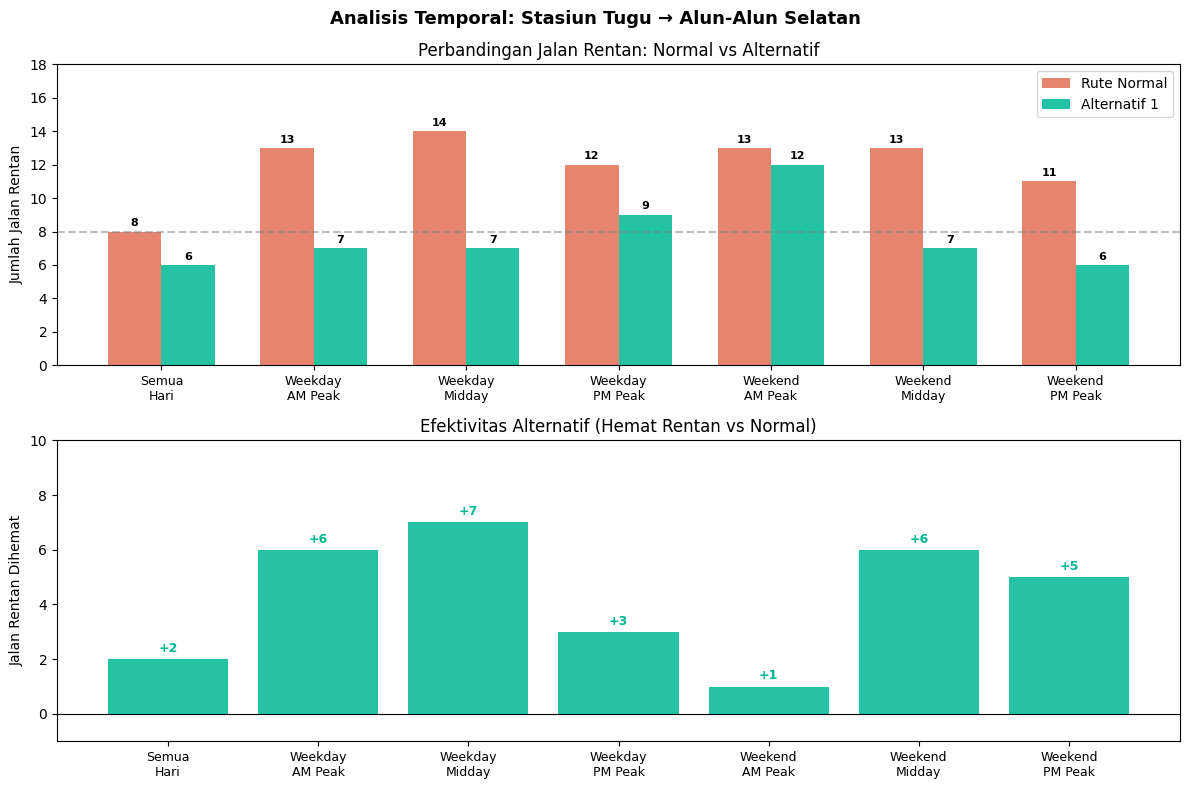

✓ Grafik tersimpan: temporal_analysis.png


In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

asal   = 'Stasiun Tugu'
tujuan = 'Alun-Alun Selatan'

slot_label = [
    'Semua\nHari',
    'Weekday\nAM Peak',
    'Weekday\nMidday',
    'Weekday\nPM Peak',
    'Weekend\nAM Peak',
    'Weekend\nMidday',
    'Weekend\nPM Peak',
]

n_normal = [8, 13, 14, 12, 13, 13, 11]
n_alt1   = [6,  7,  7,  9, 12,  7,  6]
hemat    = [r0 - r1 for r0, r1 in zip(n_normal, n_alt1)]

x = np.arange(len(slot_label))
w = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle(f'Analisis Temporal: {asal} → {tujuan}',
             fontsize=13, fontweight='bold')

# ── Grafik 1: Normal vs Alt 1 ──
bars1 = ax1.bar(x - w/2, n_normal, w,
                label='Rute Normal', color='#e17055', alpha=0.85)
bars2 = ax1.bar(x + w/2, n_alt1,   w,
                label='Alternatif 1', color='#00b894', alpha=0.85)

ax1.set_ylabel('Jumlah Jalan Rentan')
ax1.set_title('Perbandingan Jalan Rentan: Normal vs Alternatif')
ax1.set_xticks(x)
ax1.set_xticklabels(slot_label, fontsize=9)
ax1.legend()
ax1.set_ylim(0, 18)
ax1.axhline(y=8, color='gray', linestyle='--',
            alpha=0.5, label='Baseline')

# Tambah label nilai
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             str(int(bar.get_height())),
             ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             str(int(bar.get_height())),
             ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Grafik 2: Hemat Rentan ──
warna_bar = ['#00b894' if h > 0 else '#d63031' for h in hemat]
bars3 = ax2.bar(x, hemat, color=warna_bar, alpha=0.85)

ax2.set_ylabel('Jalan Rentan Dihemat')
ax2.set_title('Efektivitas Alternatif (Hemat Rentan vs Normal)')
ax2.set_xticks(x)
ax2.set_xticklabels(slot_label, fontsize=9)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylim(-1, 10)

for bar, h in zip(bars3, hemat):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.15,
             f'+{h}' if h > 0 else str(h),
             ha='center', va='bottom',
             fontsize=9, fontweight='bold',
             color='#00b894' if h > 0 else '#d63031')

plt.tight_layout()
plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grafik tersimpan: temporal_analysis.png")